# Import Libraries

In [ ]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=e36adbebaffc0d932d6eaba18707b0d9c40398df47fedcffc538e072fdecb7e7
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import scorecardpy as sc
import joblib
import json

### Loading Data

In [ ]:
df=pd.read_excel("credit_risk.xls")

# EDA

In [ ]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [ ]:
# Rename mapping
rename_dict = {
    'Unnamed: 0': 'ID',
    'X1': 'LIMIT_BAL',
    'X2': 'GENDER',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6',
    'Y': 'DEFAULT_NEXT_MONTH'
}

# Apply rename
df = df.rename(columns=rename_dict)

# Check
print(df.head())


   ID  LIMIT_BAL GENDER  ...  PAY_AMT5  PAY_AMT6          DEFAULT_NEXT_MONTH
0  ID  LIMIT_BAL    SEX  ...  PAY_AMT5  PAY_AMT6  default payment next month
1   1      20000      2  ...         0         0                           1
2   2     120000      2  ...         0      2000                           1
3   3      90000      2  ...      1000      5000                           0
4   4      50000      2  ...      1069      1000                           0

[5 rows x 25 columns]


In [ ]:
df = df.iloc[1:].reset_index(drop=True)

In [ ]:
df.head()

,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


| **Variable Name**    | **Description**                                                                                                  |
| -------------------- | ---------------------------------------------------------------------------------------------------------------- |
| `ID`                 | Unique identifier for each credit card client.                                                                   |
| `LIMIT_BAL`          | Amount of credit granted (in Dollars). This includes both individual and supplementary credit.        |
| `SEX`                | Gender of the client (1 = Male, 2 = Female).                                                                     |
| `EDUCATION`          | Education level of the client:<br>- 1 = Graduate School<br>- 2 = University<br>- 3 = High School<br>- 4 = Others |
| `MARRIAGE`           | Marital status:<br>- 1 = Married<br>- 2 = Single<br>- 3 = Others                                                 |
| `AGE`                | Age of the client in years.                                                                                      |
| `PAY_0`              | Repayment status in September 2005: how late payments were (negative = paid on time).                            |
| `PAY_2`              | Repayment status in August 2005 (same scale).                                                                    |
| `PAY_3`              | Repayment status in July 2005.                                                                                   |
| `PAY_4`              | Repayment status in June 2005.                                                                                   |
| `PAY_5`              | Repayment status in May 2005.                                                                                    |
| `PAY_6`              | Repayment status in April 2005.                                                                                  |
| `BILL_AMT1`          | Amount of bill statement in September 2005 (NT dollar).                                                          |
| `BILL_AMT2`          | Amount of bill statement in August 2005.                                                                         |
| `BILL_AMT3`          | Amount of bill statement in July 2005.                                                                           |
| `BILL_AMT4`          | Amount of bill statement in June 2005.                                                                           |
| `BILL_AMT5`          | Amount of bill statement in May 2005.                                                                            |
| `BILL_AMT6`          | Amount of bill statement in April 2005.                                                                          |
| `PAY_AMT1`           | Amount paid in September 2005 (NT dollar).                                                                       |
| `PAY_AMT2`           | Amount paid in August 2005.                                                                                      |
| `PAY_AMT3`           | Amount paid in July 2005.                                                                                        |
| `PAY_AMT4`           | Amount paid in June 2005.                                                                                        |
| `PAY_AMT5`           | Amount paid in May 2005.                                                                                         |
| `PAY_AMT6`           | Amount paid in April 2005.                                                                                       |
| `DEFAULT_NEXT_MONTH` | Target variable indicating whether the client defaulted on payment next month (0 = No, 1 = Yes).                 |


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  30000 non-null  object
 1   LIMIT_BAL           30000 non-null  object
 2   GENDER              30000 non-null  object
 3   EDUCATION           30000 non-null  object
 4   MARRIAGE            30000 non-null  object
 5   AGE                 30000 non-null  object
 6   PAY_0               30000 non-null  object
 7   PAY_2               30000 non-null  object
 8   PAY_3               30000 non-null  object
 9   PAY_4               30000 non-null  object
 10  PAY_5               30000 non-null  object
 11  PAY_6               30000 non-null  object
 12  BILL_AMT1           30000 non-null  object
 13  BILL_AMT2           30000 non-null  object
 14  BILL_AMT3           30000 non-null  object
 15  BILL_AMT4           30000 non-null  object
 16  BILL_AMT5           30

In [ ]:
# Convert appropriate columns to numeric
num_cols = [
    'LIMIT_BAL', 'AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

df.drop(columns="ID")

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [ ]:
df.describe()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [ ]:
df.shape

(30000, 25)

In [ ]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
GENDER,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


I structured EDA by credit risk dimensions: borrower demographics, exposure, repayment behavior, billing patterns, and payment capacity, rather than analyzing features individually

## Target Variable Analysis - Default Behaviour

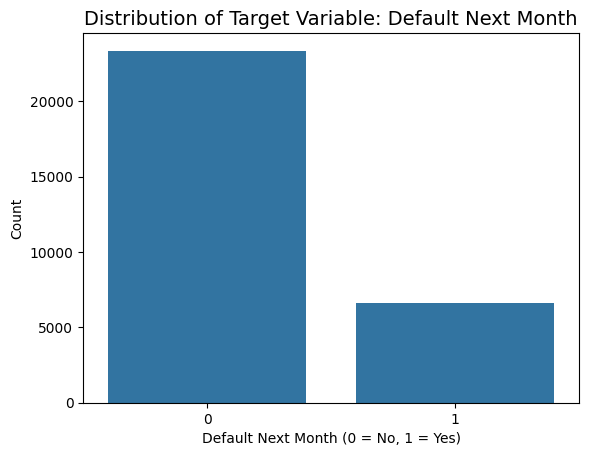

In [ ]:
sns.countplot(data=df, x="DEFAULT_NEXT_MONTH")
plt.title("Distribution of Target Variable: Default Next Month", fontsize=14)
plt.xlabel("Default Next Month (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [ ]:
default_count = df['DEFAULT_NEXT_MONTH'].value_counts().get(1, 0)
total_count = len(df)
default_percentage = (default_count / total_count) * 100

print(f"Default Percentage: {default_percentage:.2f}%")

Default Percentage: 22.12%


## Customer Demographics

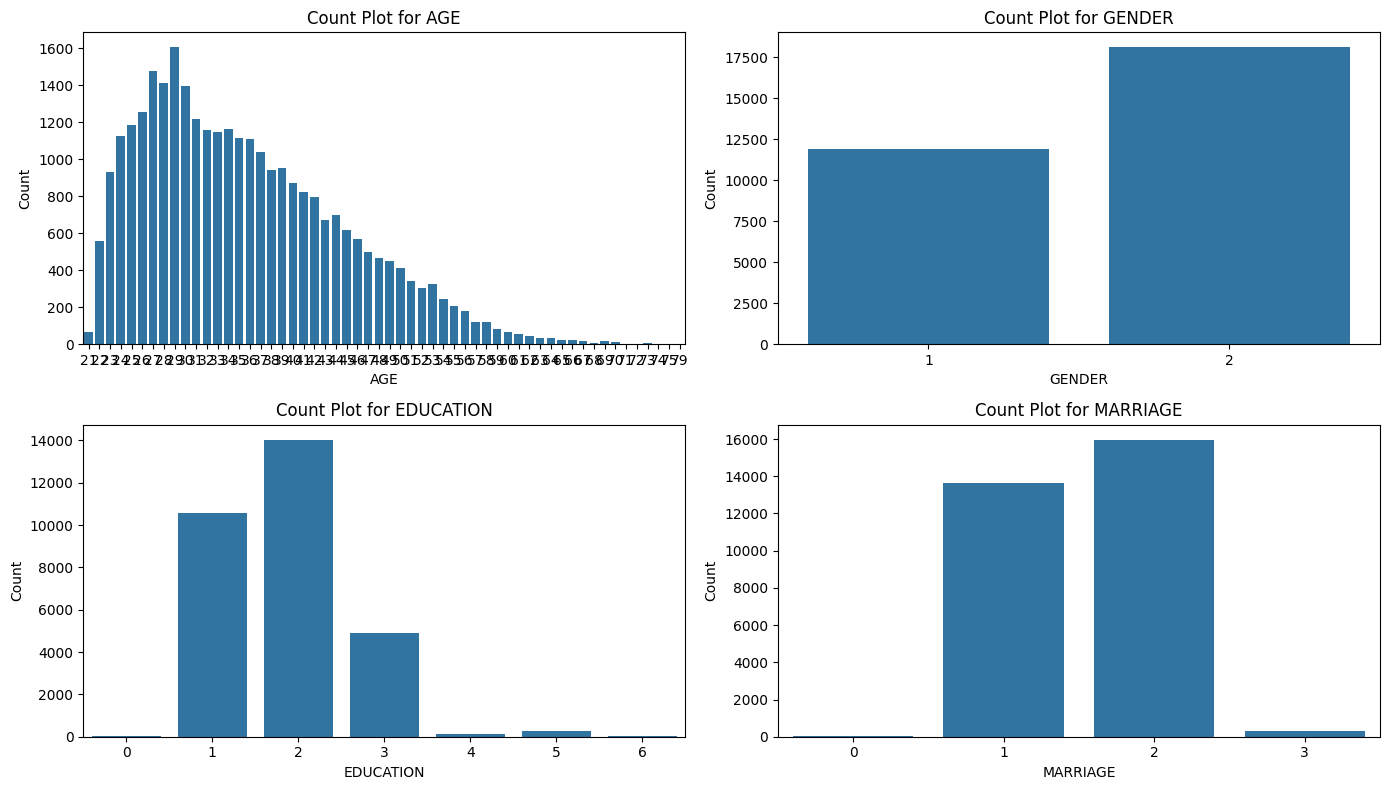

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes = axes.flatten()

cate_cols = ['AGE', 'GENDER', 'EDUCATION', 'MARRIAGE']

for ax, col in zip(axes, cate_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Count Plot for {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


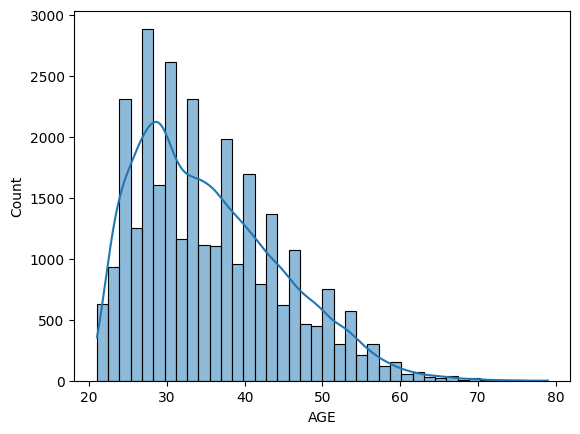

In [ ]:
sns.histplot(data=df, x='AGE', bins=40, kde=True)
plt.show()

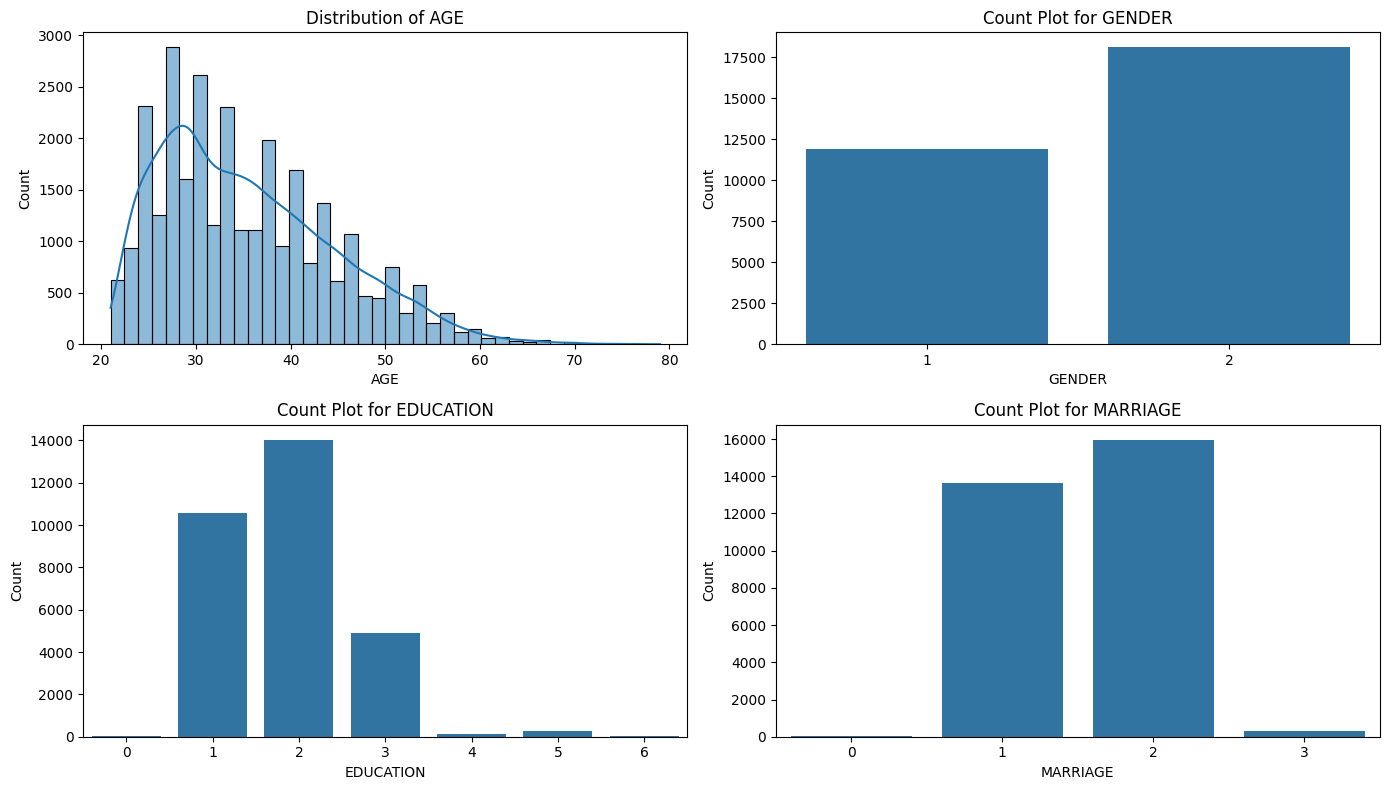

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes = axes.flatten()

cate_cols = ['AGE', 'GENDER', 'EDUCATION', 'MARRIAGE']

for ax, col in zip(axes, cate_cols):

    if col == 'AGE':
        sns.histplot(data=df, x=col, bins=40, kde=True, ax=ax)
        ax.set_title('Distribution of AGE')
    else:
        sns.countplot(data=df, x=col, ax=ax)
        ax.set_title(f'Count Plot for {col}')

    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby(['GENDER', 'DEFAULT_NEXT_MONTH']).size().reset_index(name='Count')

,GENDER,DEFAULT_NEXT_MONTH,Count
0,1,0,9015
1,1,1,2873
2,2,0,14349
3,2,1,3763


In [ ]:
df.groupby(['MARRIAGE', 'DEFAULT_NEXT_MONTH']).size().reset_index(name='Count')

,MARRIAGE,DEFAULT_NEXT_MONTH,Count
0,0,0,49
1,0,1,5
2,1,0,10453
3,1,1,3206
4,2,0,12623
5,2,1,3341
6,3,0,239
7,3,1,84


In [ ]:
df.groupby(['EDUCATION', 'DEFAULT_NEXT_MONTH']).size().reset_index(name='Count')

,EDUCATION,DEFAULT_NEXT_MONTH,Count
0,0,0,14
1,1,0,8549
2,1,1,2036
3,2,0,10700
4,2,1,3330
5,3,0,3680
6,3,1,1237
7,4,0,116
8,4,1,7
9,5,0,262


Undocumented categorical values in marital status and education were mapped to the ‘Others’ category instead of being dropped, to avoid bias and information loss.

In [ ]:
# Apply mapping
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Verify mapping
print(df['MARRIAGE'].value_counts())

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


/tmp/ipykernel_6528/2829123377.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)


In [ ]:
# Apply mapping
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Verify mapping
print(df['EDUCATION'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


/tmp/ipykernel_6528/4163520908.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)


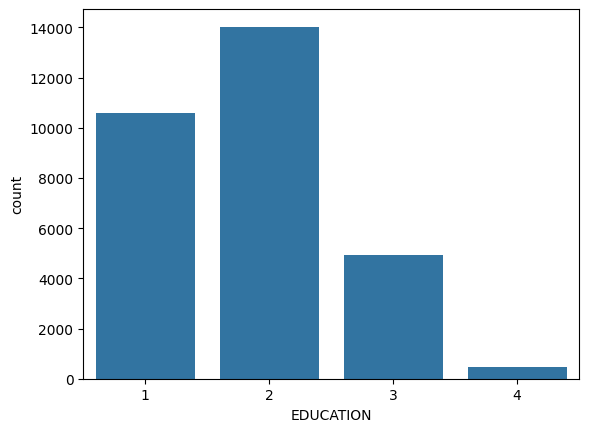

In [ ]:
sns.countplot(data=df, x="EDUCATION")
plt.show()

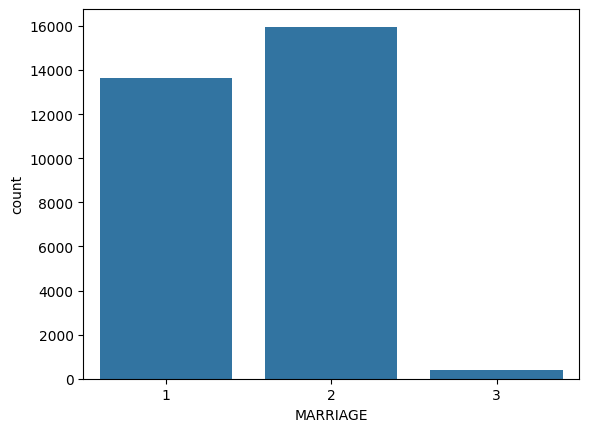

In [ ]:
sns.countplot(data=df, x="MARRIAGE")
plt.show()

## Credit Exposure & Limit Analysis

### Distribution of Credit Limit

In [ ]:
print(f"Minimum LIMIT_BAL: {df['LIMIT_BAL'].min()}")
print(f"Maximum LIMIT_BAL: {df['LIMIT_BAL'].max()}")

Minimum LIMIT_BAL: 10000
Maximum LIMIT_BAL: 1000000


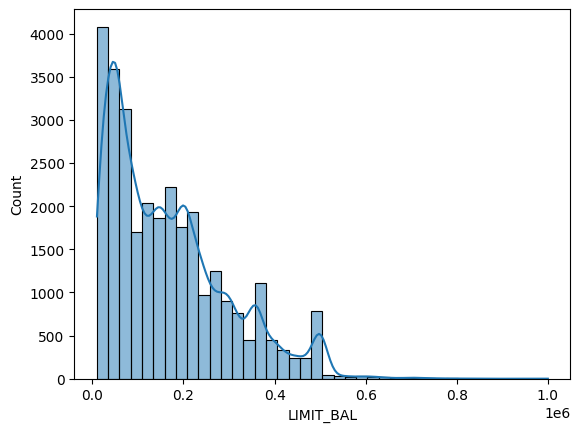

In [ ]:
sns.histplot(data=df, x='LIMIT_BAL', bins=40, kde=True)
plt.show()

The credit limit distribution is strongly right-skewed, indicating that most customers belong to lower exposure segments, while a small proportion of customers hold very high credit limits. This suggests a portfolio dominated by retail/subprime to near-prime borrowers, with concentrated exposure risk in a limited number of high-limit accounts

### Default Rate by Credit Limit Buckets

/tmp/ipykernel_6528/278414876.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('LIMIT_BUCKET')["DEFAULT_NEXT_MONTH"]


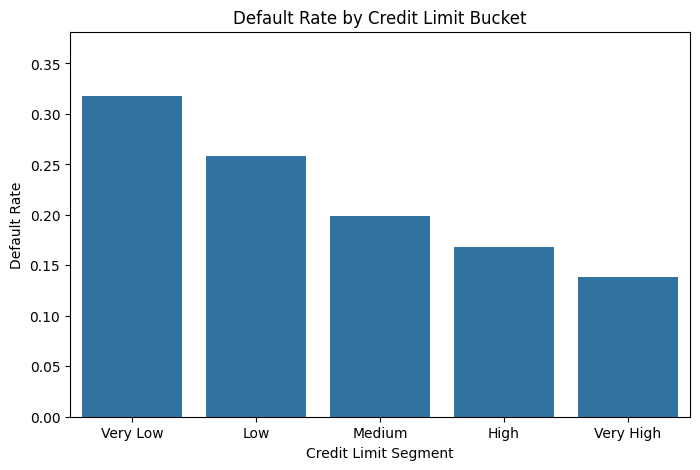

In [ ]:
df['LIMIT_BUCKET'] = pd.qcut(
    df['LIMIT_BAL'],
    q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
limit_default_rate = (
    df.groupby('LIMIT_BUCKET')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=limit_default_rate, x='LIMIT_BUCKET', y="DEFAULT_NEXT_MONTH")
plt.title('Default Rate by Credit Limit Bucket')
plt.xlabel('Credit Limit Segment')
plt.ylabel('Default Rate')
plt.ylim(0, limit_default_rate["DEFAULT_NEXT_MONTH"].max() * 1.2)
plt.show()


### LIMIT_BAL vs DEFAULT

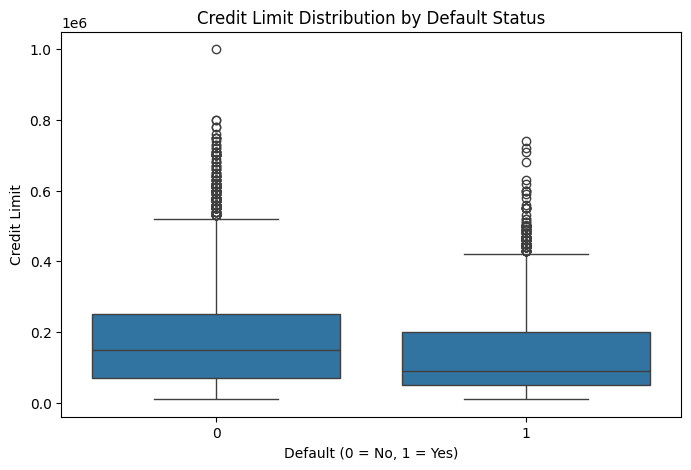

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="DEFAULT_NEXT_MONTH", y='LIMIT_BAL')
plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit')
plt.show()


There appears to be an inverse relationship between credit limit and the likelihood of default. Clients with lower credit limits are more prone to defaulting.

## Repayment Behaviour Analysis

### Distribution of Repayment Status (Delay Severity)

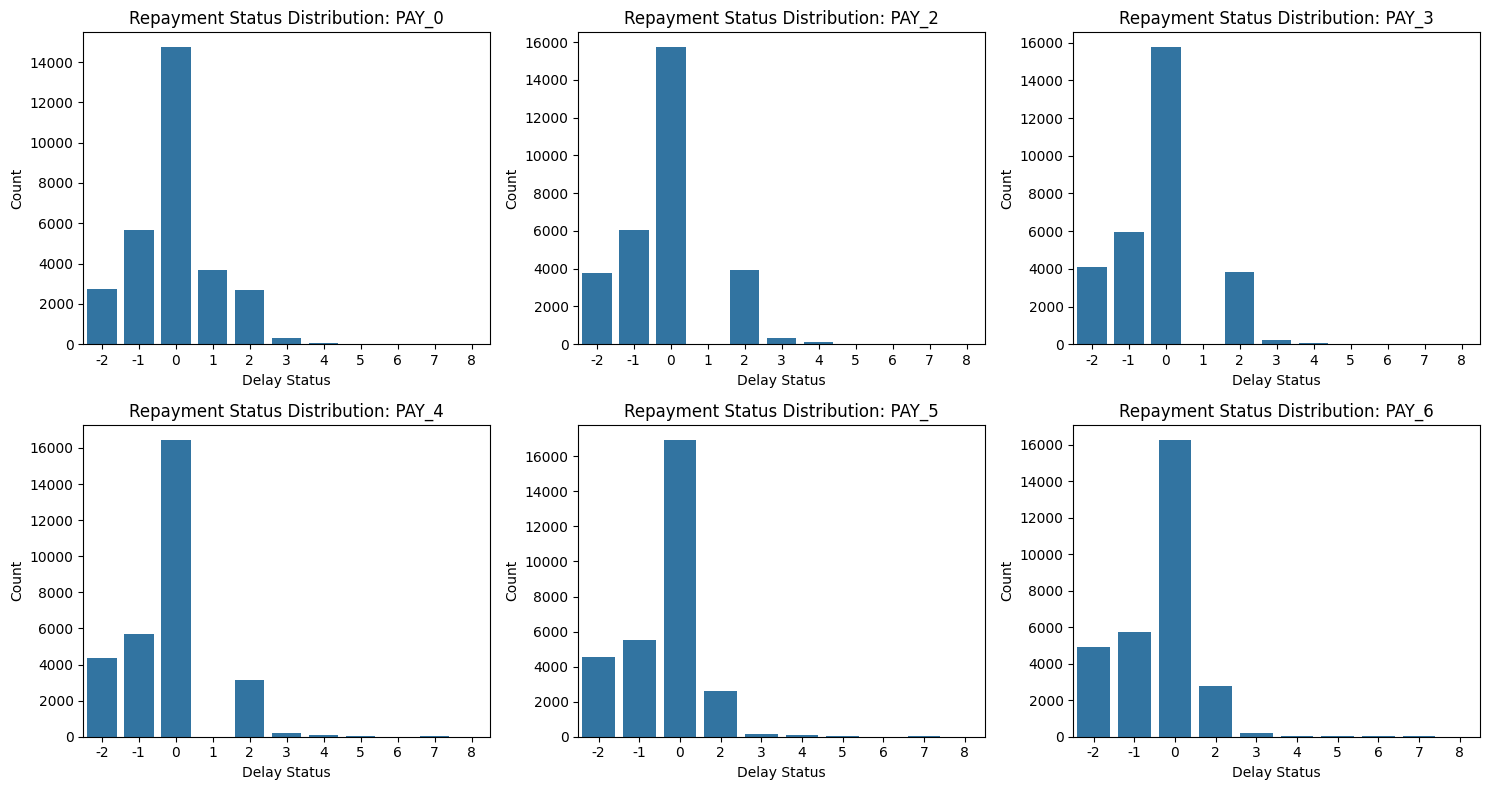

In [ ]:
pay_cols=["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Repayment Status Distribution: {col}')
    ax.set_xlabel('Delay Status')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [ ]:
df

,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH,LIMIT_BUCKET
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Very Low
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Medium
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Low
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Very Low
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0,High
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0,Medium
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1,Very Low
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1,Low


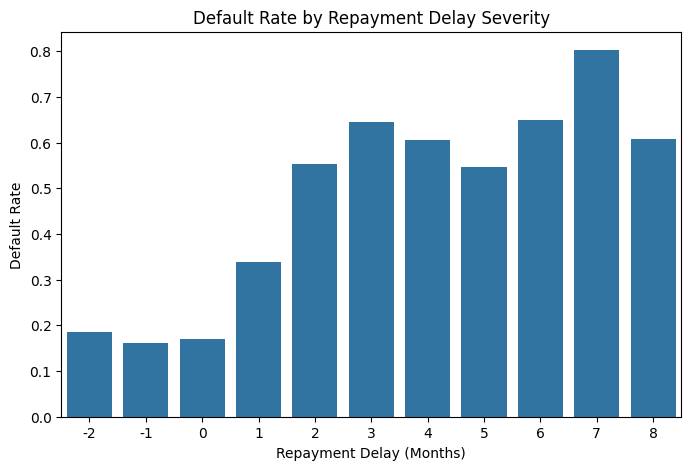

In [ ]:
pay_melt = df.melt(
    id_vars='DEFAULT_NEXT_MONTH',
    value_vars=['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'],
    var_name='MONTH',
    value_name='DELAY'
)

delay_default = (
    pay_melt
    .groupby('DELAY')['DEFAULT_NEXT_MONTH']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=delay_default, x='DELAY', y='DEFAULT_NEXT_MONTH')
plt.title('Default Rate by Repayment Delay Severity')
plt.xlabel('Repayment Delay (Months)')
plt.ylabel('Default Rate')
plt.show()


### Default Rate by Repayment Delay

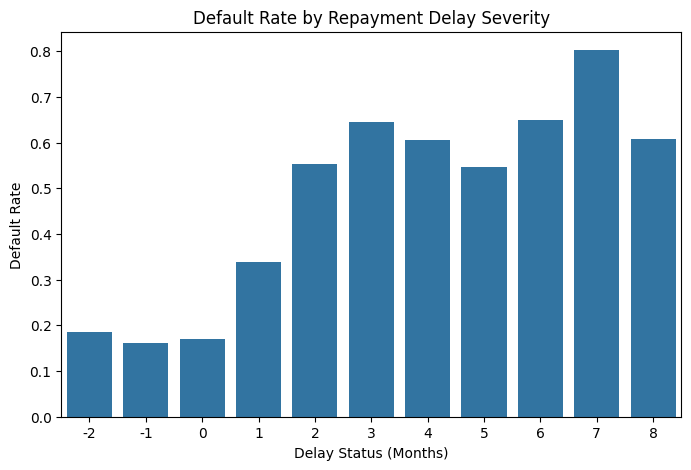

In [ ]:
pay_melt = df.melt(
    id_vars="DEFAULT_NEXT_MONTH",
    value_vars=pay_cols,
    var_name='PAY_MONTH',
    value_name='DELAY'
)
delay_default_rate = (
    pay_melt
    .groupby('DELAY')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=delay_default_rate, x='DELAY', y="DEFAULT_NEXT_MONTH")
plt.title('Default Rate by Repayment Delay Severity')
plt.xlabel('Delay Status (Months)')
plt.ylabel('Default Rate')
plt.show()


### Maximum Delay vs Default

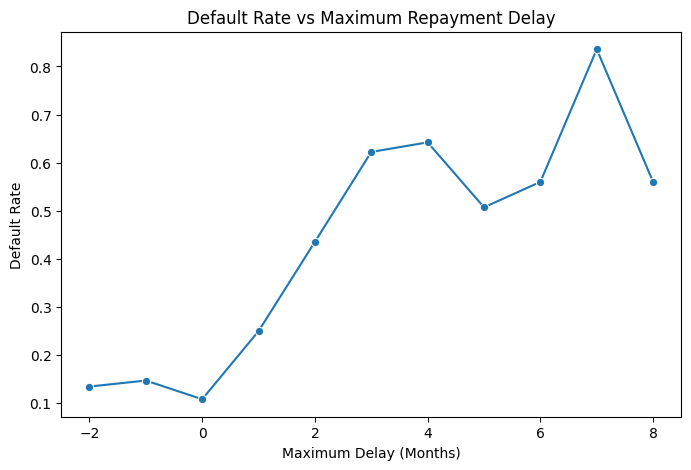

In [ ]:
df['MAX_DELAY'] = df[pay_cols].max(axis=1)
max_delay_default = (
    df.groupby('MAX_DELAY')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.lineplot(data=max_delay_default, x='MAX_DELAY', y="DEFAULT_NEXT_MONTH", marker='o')
plt.title('Default Rate vs Maximum Repayment Delay')
plt.xlabel('Maximum Delay (Months)')
plt.ylabel('Default Rate')
plt.show()


### Frequency of Delinquencies

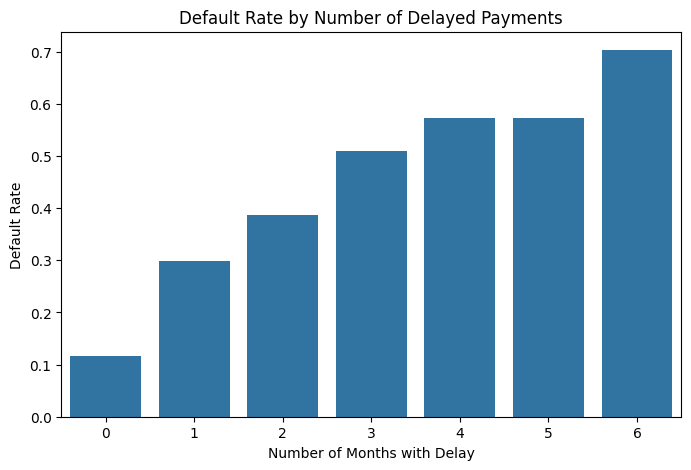

In [ ]:
df['NUM_DELAYS'] = (df[pay_cols] >= 1).sum(axis=1)
delay_count_default = (
    df.groupby('NUM_DELAYS')["DEFAULT_NEXT_MONTH"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=delay_count_default, x='NUM_DELAYS', y="DEFAULT_NEXT_MONTH")
plt.title('Default Rate by Number of Delayed Payments')
plt.xlabel('Number of Months with Delay')
plt.ylabel('Default Rate')
plt.show()


### Clean On-Time vs Delinquent Segmentation

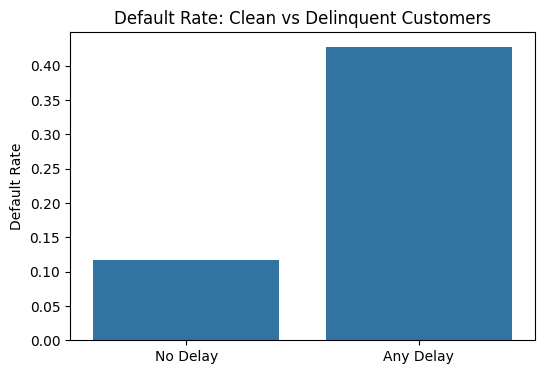

In [ ]:
df['ANY_DELAY_FLAG'] = (df[pay_cols] >= 1).any(axis=1).astype(int)
df.groupby('ANY_DELAY_FLAG')["DEFAULT_NEXT_MONTH"].mean()
plt.figure(figsize=(6,4))
sns.barplot(
    x=['No Delay', 'Any Delay'],
    y=df.groupby('ANY_DELAY_FLAG')["DEFAULT_NEXT_MONTH"].mean().values
)
plt.title('Default Rate: Clean vs Delinquent Customers')
plt.ylabel('Default Rate')
plt.show()


## Billing Amount Analysis

### Distribution of Billing Amounts (Debt Exposure)

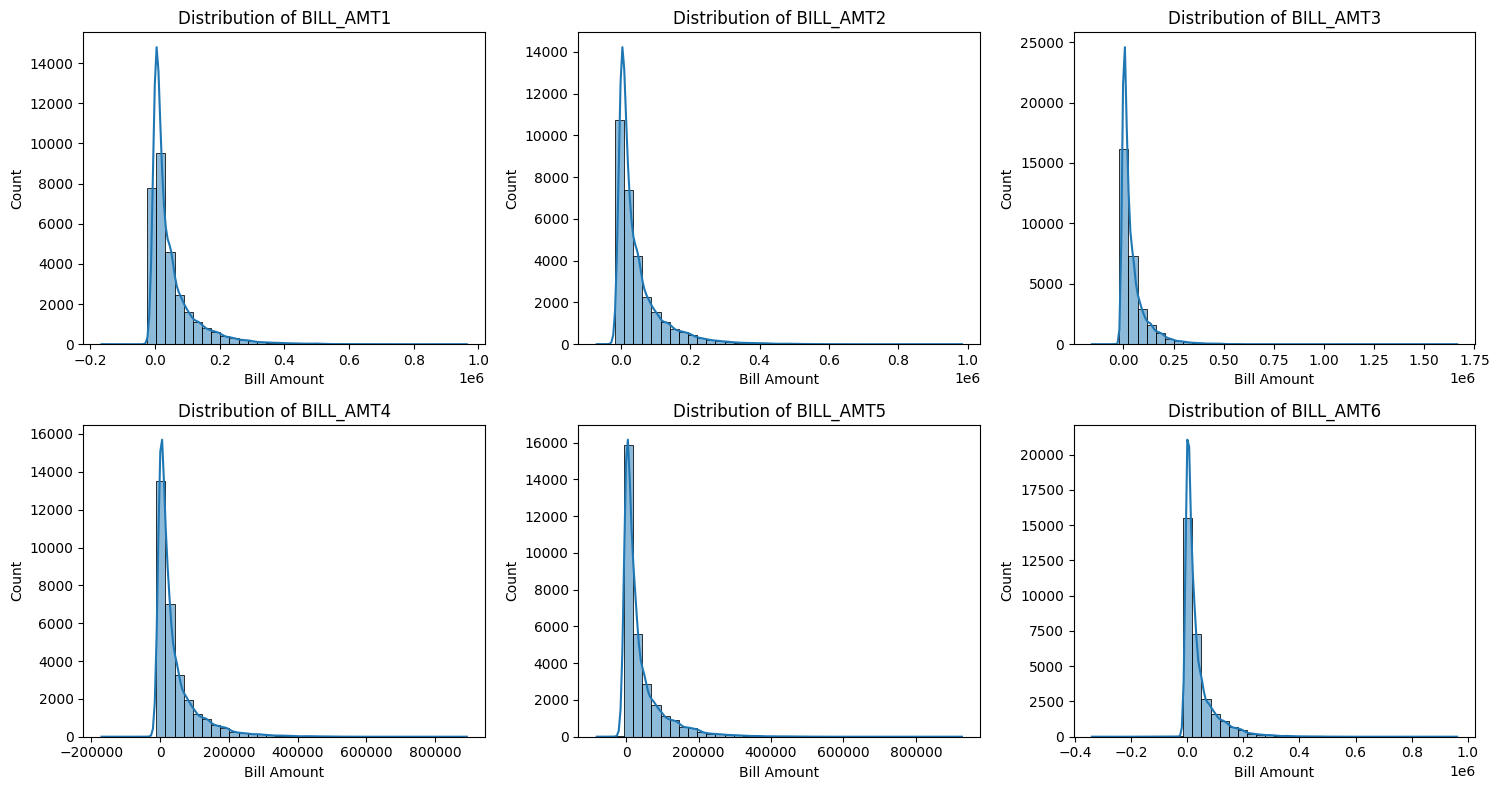

In [ ]:
bill_cols = [
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6'
]
target = 'DEFAULT_NEXT_MONTH'

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, bill_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Bill Amount')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Billing Amount vs Default

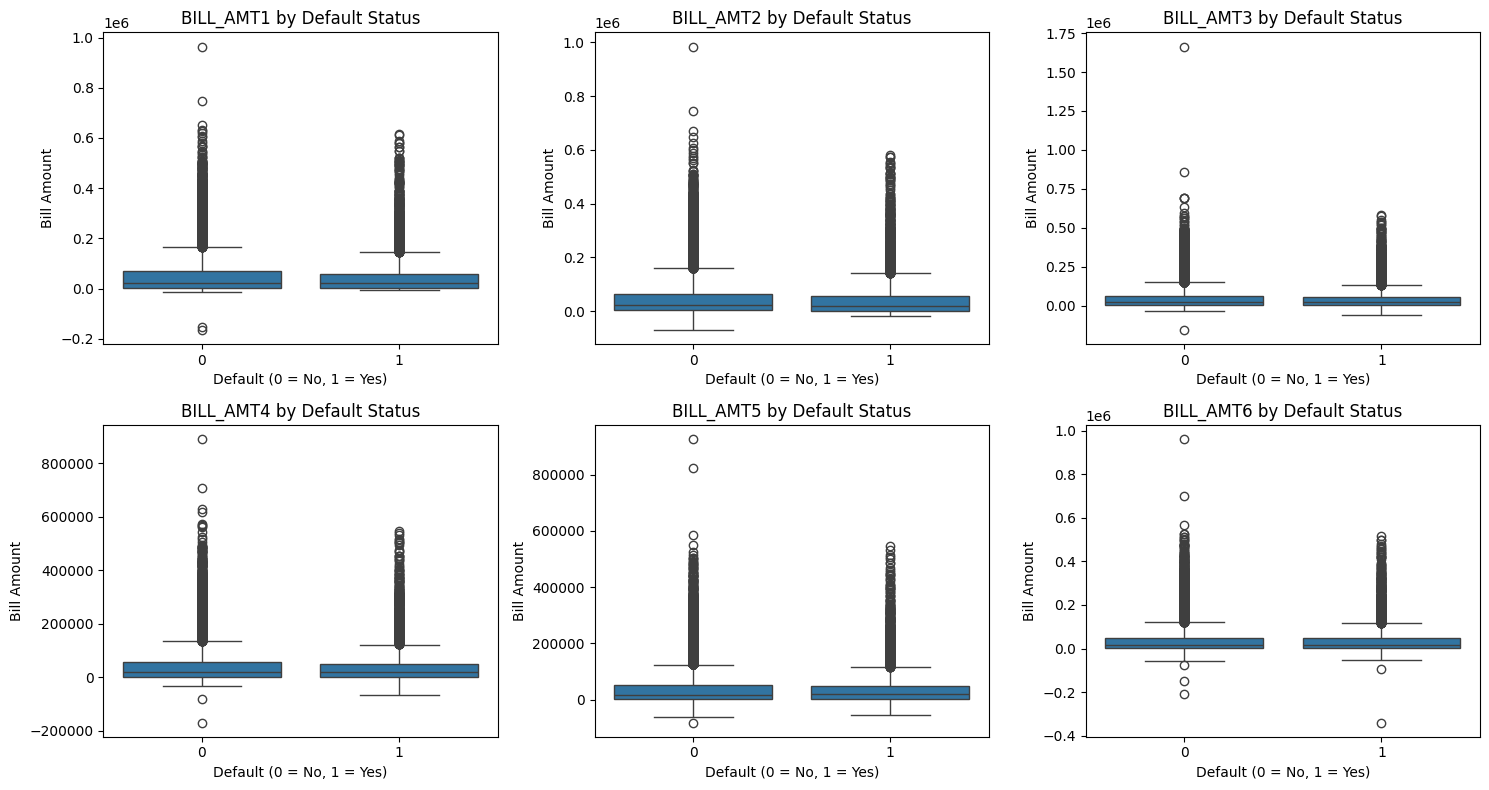

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, bill_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel('Bill Amount')

plt.tight_layout()
plt.show()


### Average Billing Trend Over Time

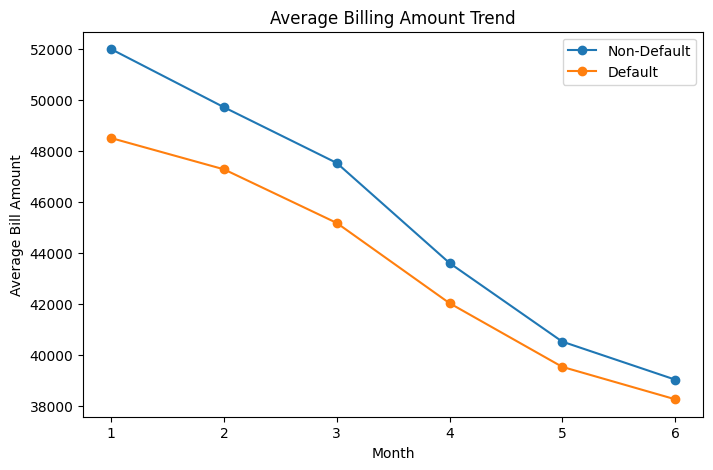

In [ ]:
bill_trend = (
    df.groupby(target)[bill_cols]
    .mean()
    .T
)

bill_trend.index = range(1, 7)  # Month index
plt.figure(figsize=(8,5))
plt.plot(bill_trend.index, bill_trend[0], marker='o', label='Non-Default')
plt.plot(bill_trend.index, bill_trend[1], marker='o', label='Default')
plt.title('Average Billing Amount Trend')
plt.xlabel('Month')
plt.ylabel('Average Bill Amount')
plt.legend()
plt.show()

### Bill Growth / Deterioration Analysis

/tmp/ipykernel_6528/4136386592.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('BILL_GROWTH_BUCKET')[target]


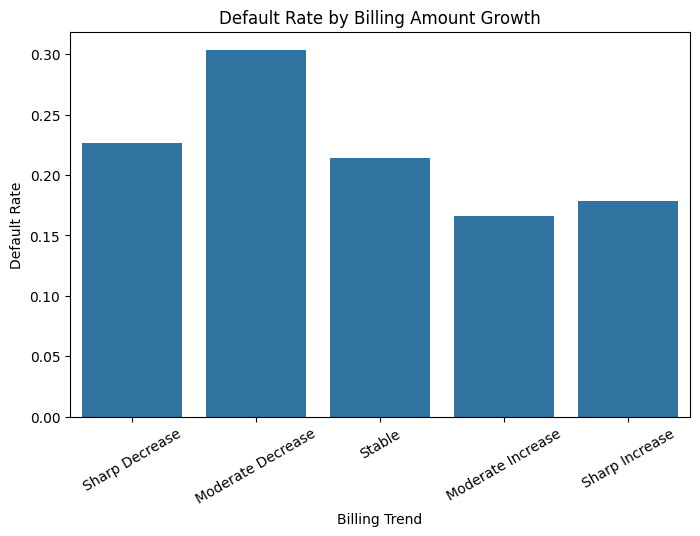

In [ ]:
df['BILL_GROWTH'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_GROWTH_BUCKET'] = pd.qcut(
    df['BILL_GROWTH'],
    q=5,
    labels=['Sharp Decrease','Moderate Decrease','Stable','Moderate Increase','Sharp Increase']
)

bill_growth_default = (
    df.groupby('BILL_GROWTH_BUCKET')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=bill_growth_default, x='BILL_GROWTH_BUCKET', y=target)
plt.title('Default Rate by Billing Amount Growth')
plt.xlabel('Billing Trend')
plt.ylabel('Default Rate')
plt.xticks(rotation=30)
plt.show()


### High Utilization Proxy (Consistent High Bills)

/tmp/ipykernel_6528/256359480.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AVG_BILL_BUCKET')[target]


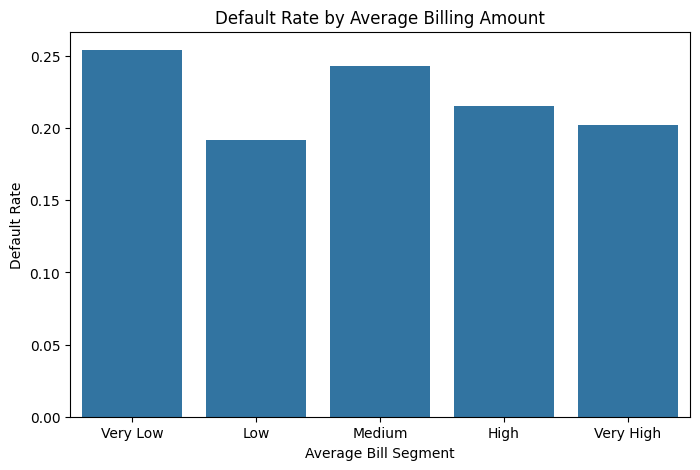

In [ ]:
df['AVG_BILL_AMT'] = df[bill_cols].mean(axis=1)
df['AVG_BILL_BUCKET'] = pd.qcut(
    df['AVG_BILL_AMT'],
    q=5,
    labels=['Very Low','Low','Medium','High','Very High']
)

avg_bill_default = (
    df.groupby('AVG_BILL_BUCKET')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=avg_bill_default, x='AVG_BILL_BUCKET', y=target)
plt.title('Default Rate by Average Billing Amount')
plt.xlabel('Average Bill Segment')
plt.ylabel('Default Rate')
plt.show()


### Correlation Among Billing Amounts (Redundancy Check)

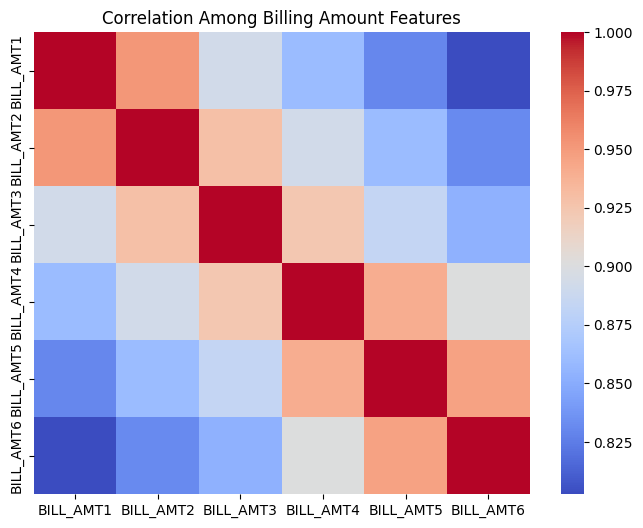

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[bill_cols].corr(),
    annot=False,
    cmap='coolwarm'
)
plt.title('Correlation Among Billing Amount Features')
plt.show()


### Payment-to-Bill Ratio (PAY_AMT / BILL_AMT) IMP - feature engineering

## Payment Amount Analysis

In [ ]:
pay_amt_cols = [
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
]
target = 'DEFAULT_NEXT_MONTH'


### Distribution of Payment Amounts (Liquidity View)

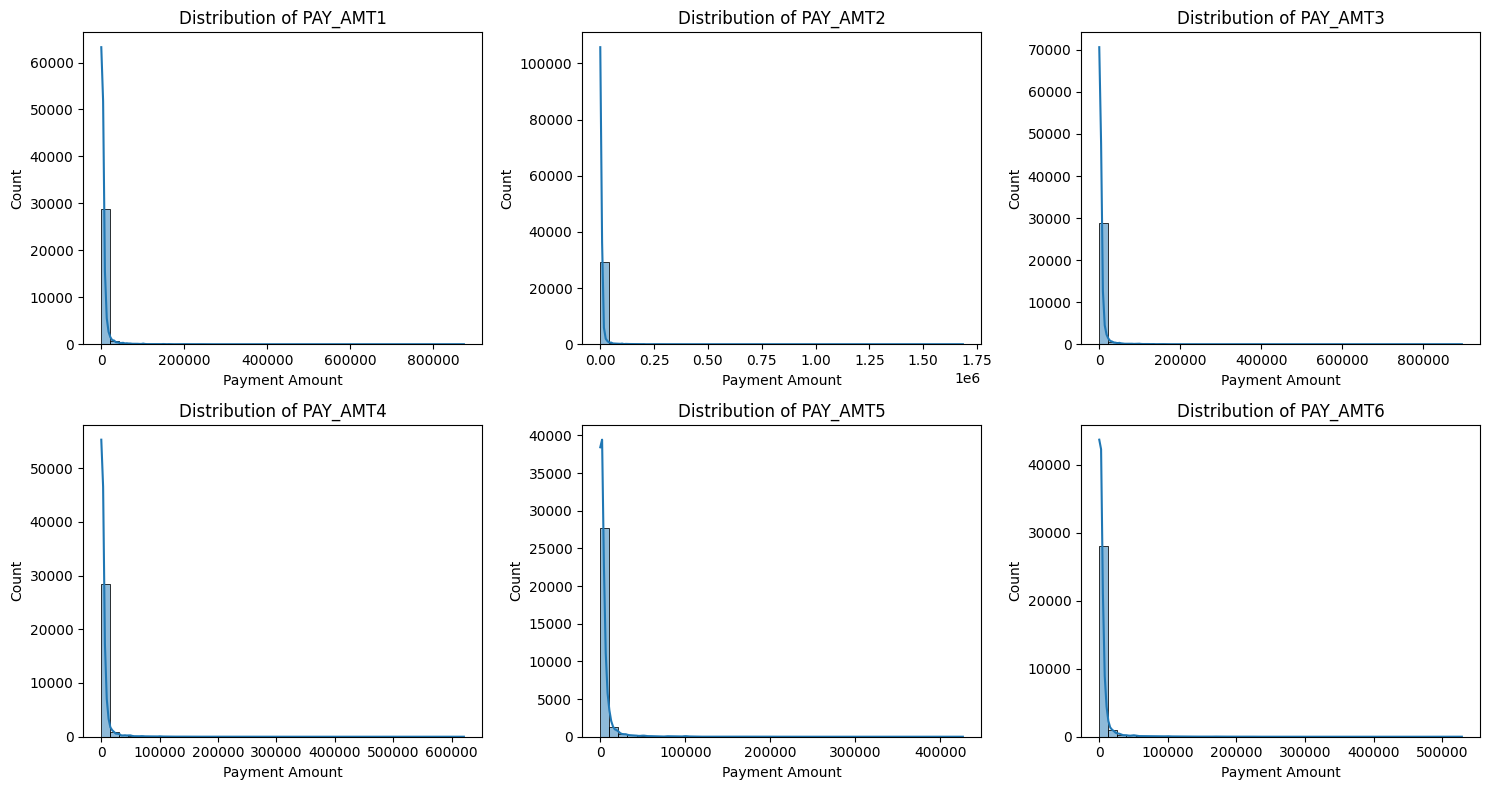

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_amt_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Payment Amount')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Payment Amount vs Default (Critical Signal)

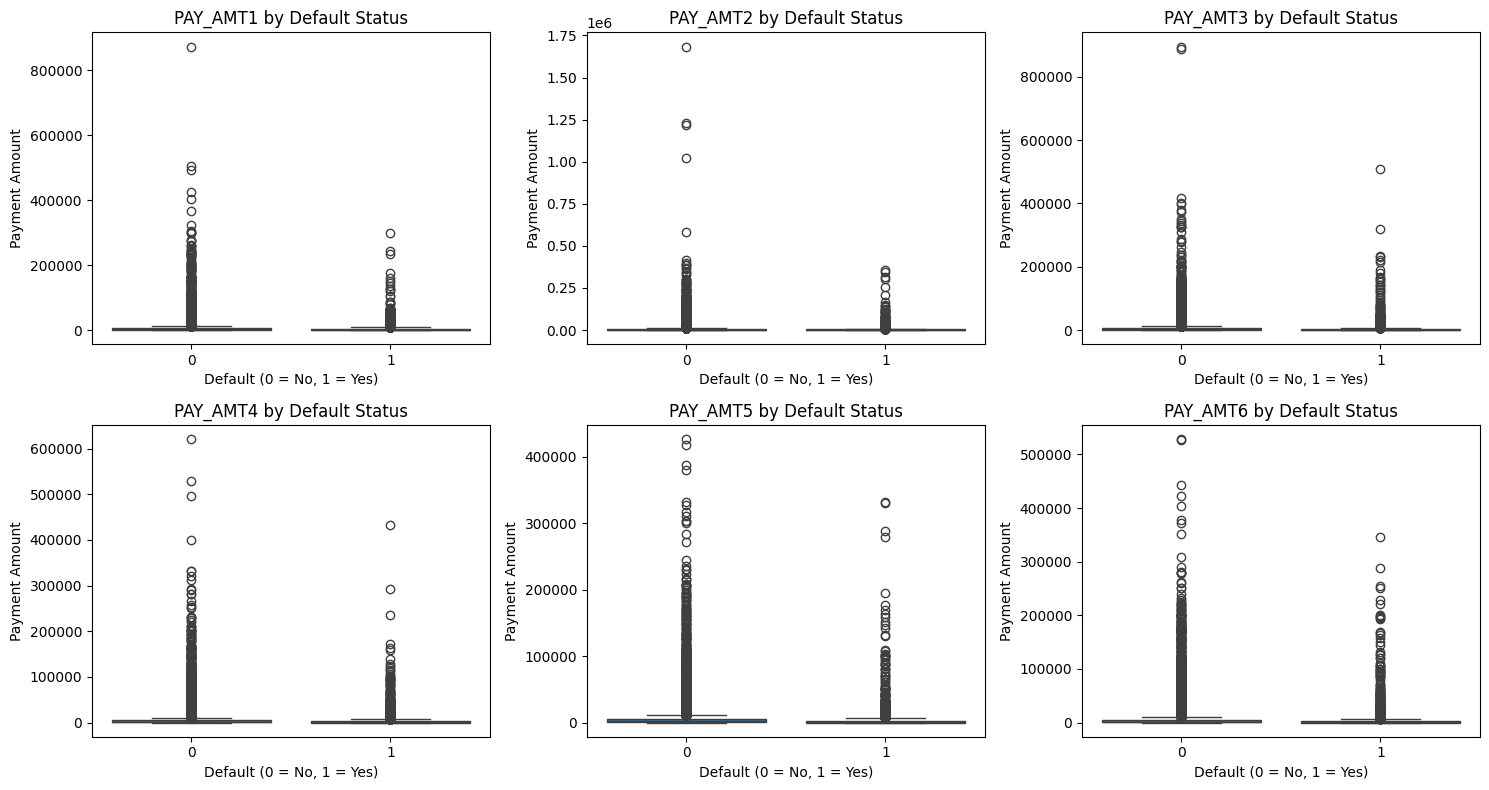

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_amt_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel('Payment Amount')

plt.tight_layout()
plt.show()


### Average Payment Trend Over Time (Behavioral Deterioration)

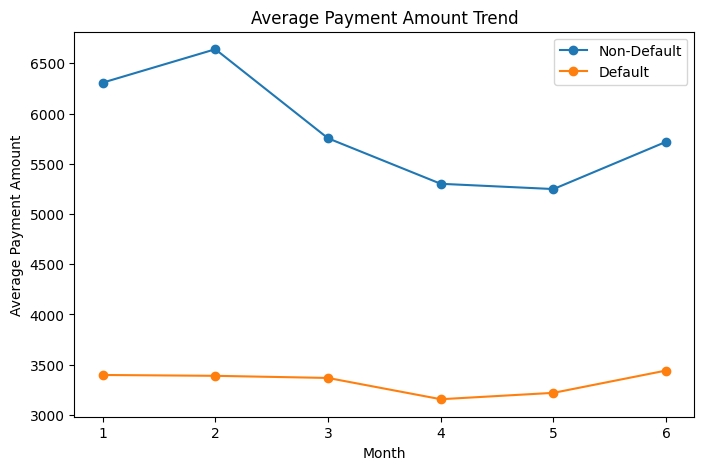

In [ ]:
payment_trend = (
    df.groupby(target)[pay_amt_cols]
    .mean()
    .T
)

payment_trend.index = range(1, 7)
plt.figure(figsize=(8,5))
plt.plot(payment_trend.index, payment_trend[0], marker='o', label='Non-Default')
plt.plot(payment_trend.index, payment_trend[1], marker='o', label='Default')
plt.title('Average Payment Amount Trend')
plt.xlabel('Month')
plt.ylabel('Average Payment Amount')
plt.legend()
plt.show()


### Zero / Minimal Payment Analysis (Early Warning)

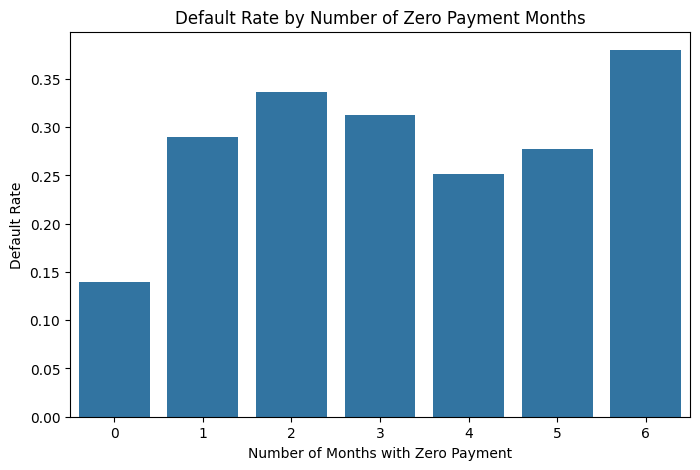

In [ ]:
for col in pay_amt_cols:
    df[col + '_ZERO_FLAG'] = (df[col] == 0).astype(int)
zero_cols = [col + '_ZERO_FLAG' for col in pay_amt_cols]
df['NUM_ZERO_PAYMENTS'] = df[zero_cols].sum(axis=1)
zero_payment_default = (
    df.groupby('NUM_ZERO_PAYMENTS')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=zero_payment_default, x='NUM_ZERO_PAYMENTS', y=target)
plt.title('Default Rate by Number of Zero Payment Months')
plt.xlabel('Number of Months with Zero Payment')
plt.ylabel('Default Rate')
plt.show()


### Payment Stability (Consistency Measure)

/tmp/ipykernel_6528/2878006103.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PAYMENT_STD_BUCKET')[target]


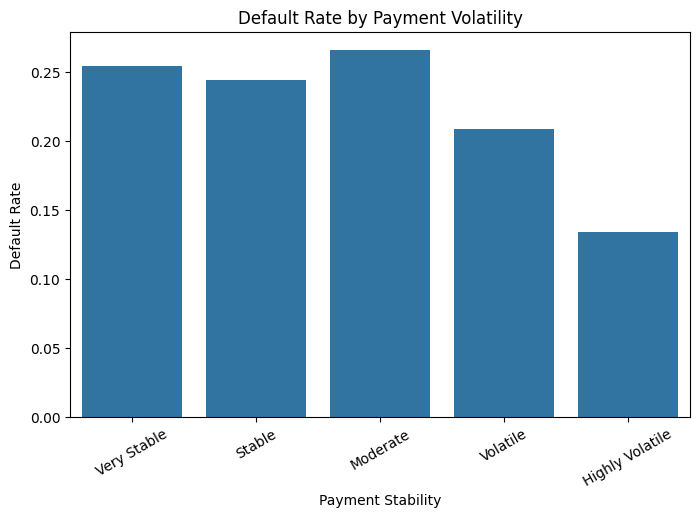

In [ ]:
df['PAYMENT_STD'] = df[pay_amt_cols].std(axis=1)
df['PAYMENT_STD_BUCKET'] = pd.qcut(
    df['PAYMENT_STD'],
    q=5,
    labels=['Very Stable','Stable','Moderate','Volatile','Highly Volatile']
)
payment_std_default = (
    df.groupby('PAYMENT_STD_BUCKET')[target]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(data=payment_std_default, x='PAYMENT_STD_BUCKET', y=target)
plt.title('Default Rate by Payment Volatility')
plt.xlabel('Payment Stability')
plt.ylabel('Default Rate')
plt.xticks(rotation=30)
plt.show()


### Correlation Among Payment Amounts (Redundancy)

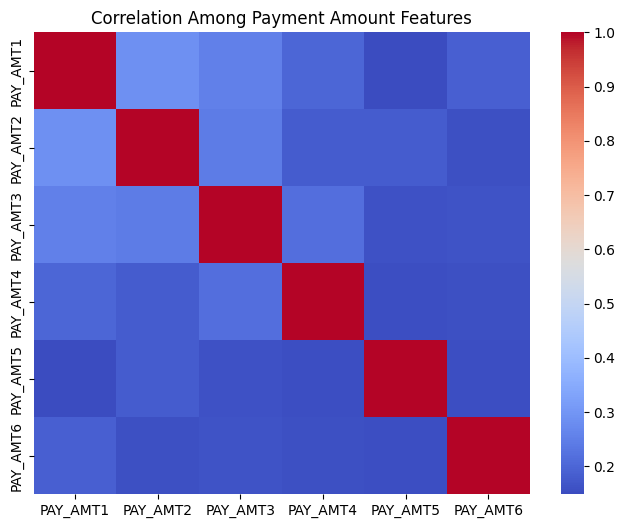

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[pay_amt_cols].corr(),
    cmap='coolwarm',
    annot=False
)
plt.title('Correlation Among Payment Amount Features')
plt.show()


## Payment-to-Bill Ratio Analysis (PAY_AMT / BILL_AMT)

In [ ]:
bill_cols = [
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6'
]

pay_amt_cols = [
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

target = 'DEFAULT_NEXT_MONTH'


In [ ]:
import numpy as np

for i in range(1, 7):
    df[f'PAY_BILL_RATIO_{i}'] = np.where(
        df[f'BILL_AMT{i}'] > 0,
        df[f'PAY_AMT{i}'] / df[f'BILL_AMT{i}'],
        0
    )


### Distribution of Payment-to-Bill Ratio

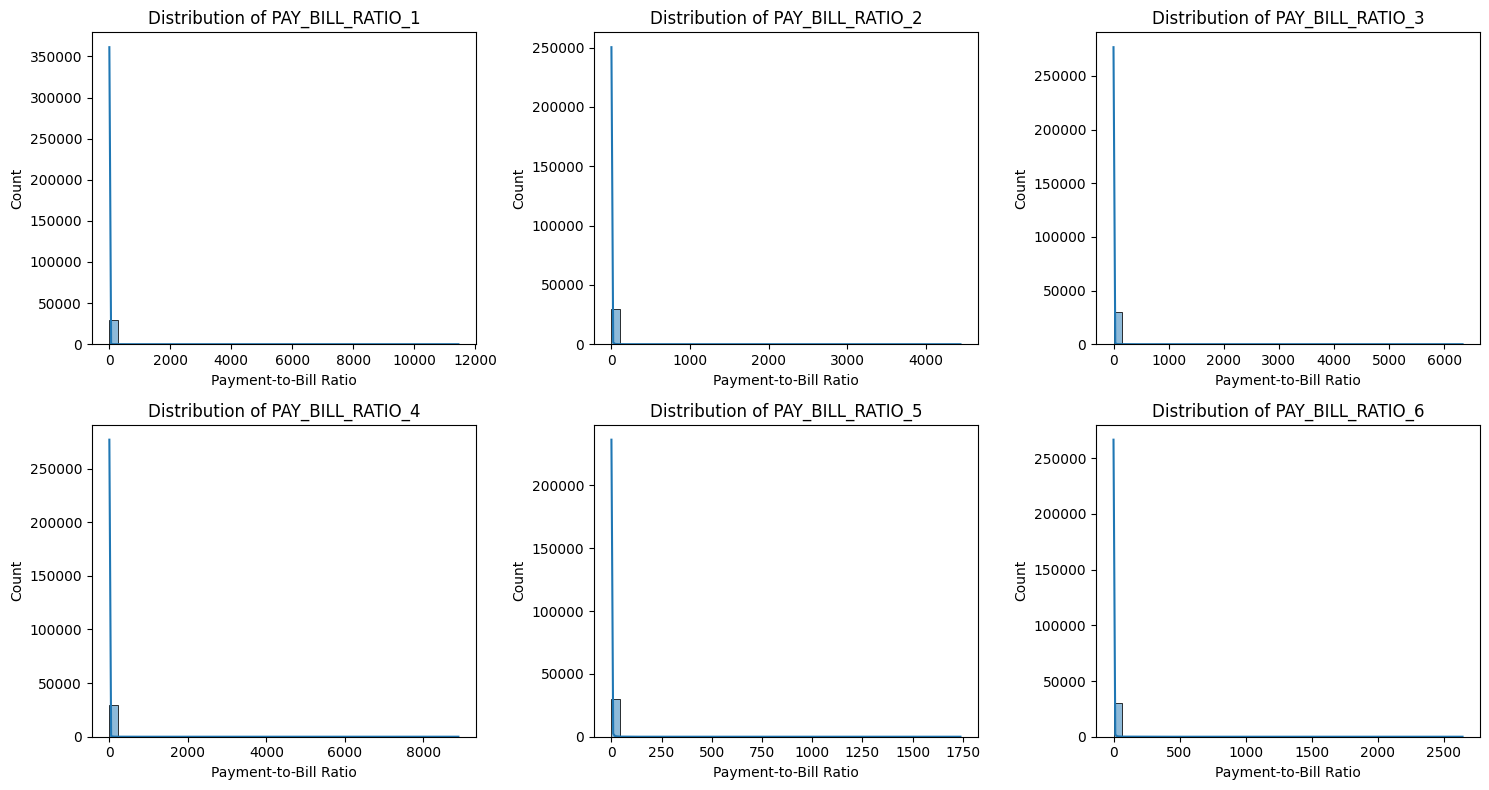

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'PAY_BILL_RATIO_{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, ratio_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Payment-to-Bill Ratio')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### Payment-to-Bill Ratio vs Default

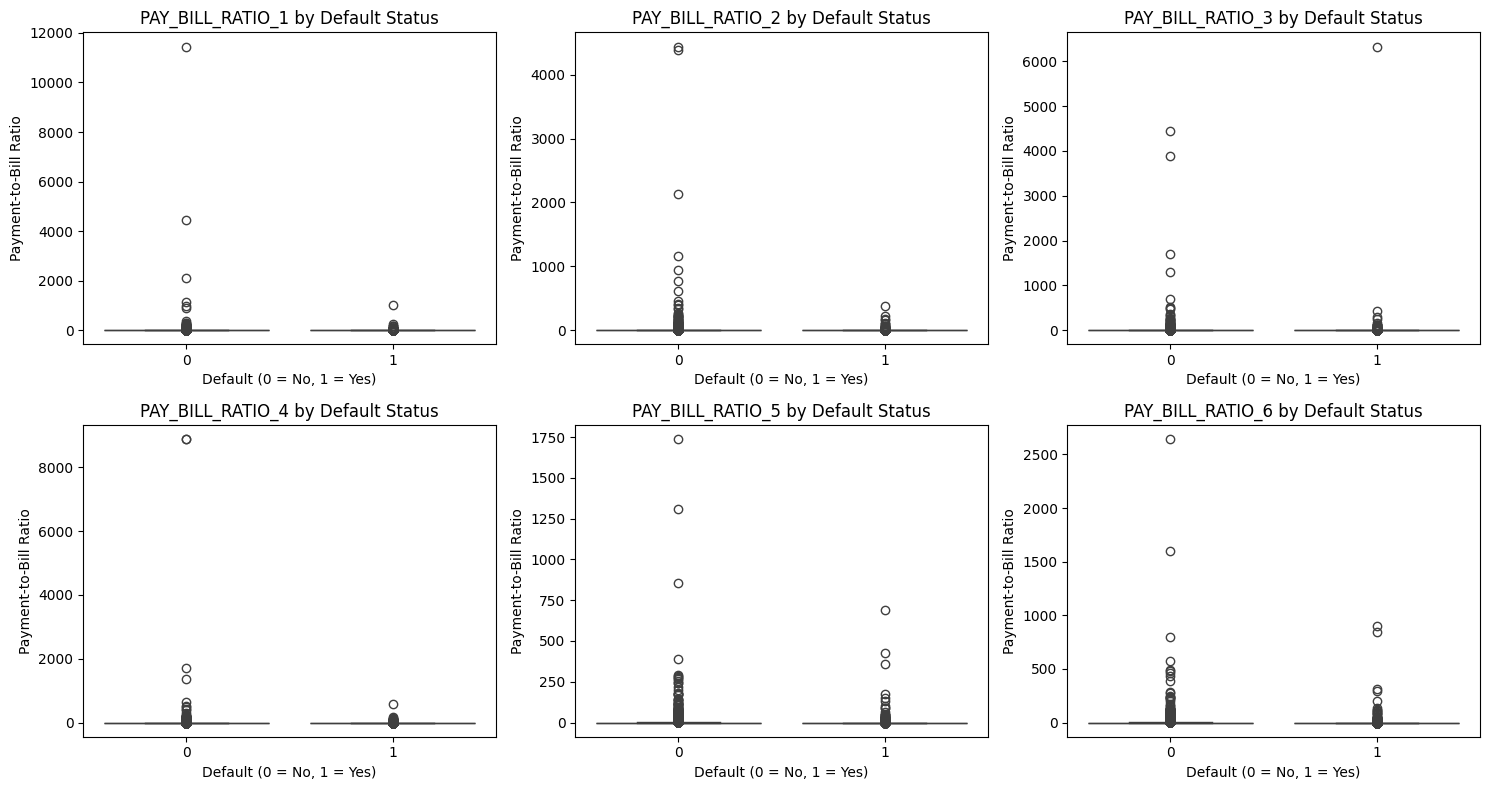

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, ratio_cols):
    sns.boxplot(data=df, x=target, y=col, ax=ax)
    ax.set_title(f'{col} by Default Status')
    ax.set_xlabel('Default (0 = No, 1 = Yes)')
    ax.set_ylabel('Payment-to-Bill Ratio')

plt.tight_layout()
plt.show()


### Average Ratio Trend Over Time (Behavioral Deterioration)

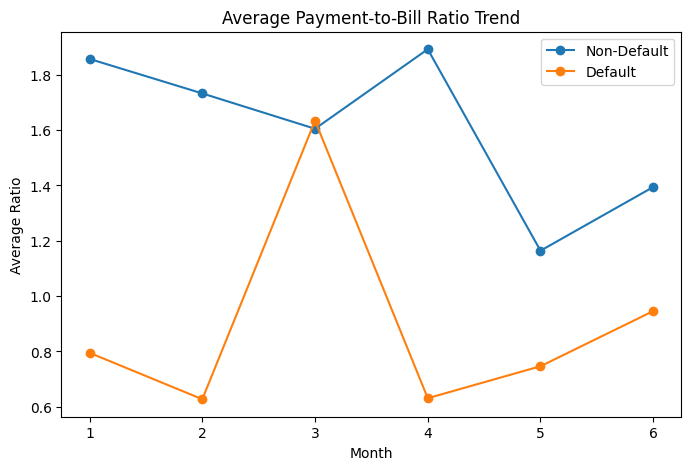

In [ ]:
ratio_trend = (
    df.groupby(target)[ratio_cols]
    .mean()
    .T
)

ratio_trend.index = range(1, 7)
plt.figure(figsize=(8,5))
plt.plot(ratio_trend.index, ratio_trend[0], marker='o', label='Non-Default')
plt.plot(ratio_trend.index, ratio_trend[1], marker='o', label='Default')
plt.title('Average Payment-to-Bill Ratio Trend')
plt.xlabel('Month')
plt.ylabel('Average Ratio')
plt.legend()
plt.show()


## Temporal Behaviour Analysis — Risk Over Time

### Month-wise Comparison — Repayment Status (PAY*)

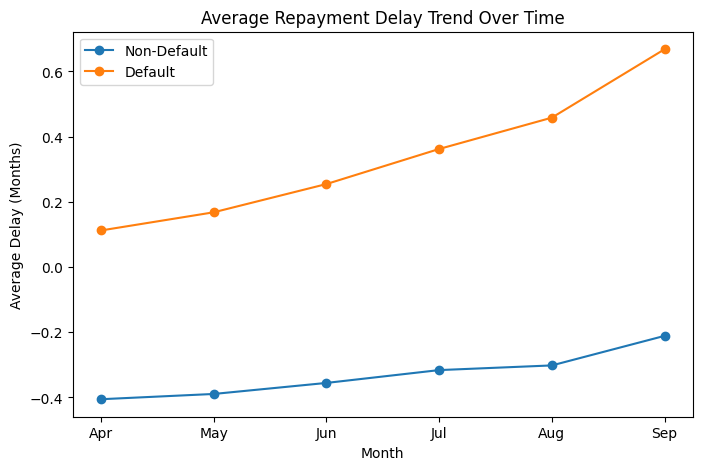

In [ ]:
pay_cols = ['PAY_6','PAY_5','PAY_4','PAY_3','PAY_2','PAY_0']  # Old → Recent
target = 'DEFAULT_NEXT_MONTH'

pay_trend = (
    df.groupby(target)[pay_cols]
    .mean()
    .T
)

pay_trend.index = ['Apr','May','Jun','Jul','Aug','Sep']

plt.figure(figsize=(8,5))
plt.plot(pay_trend.index, pay_trend[0], marker='o', label='Non-Default')
plt.plot(pay_trend.index, pay_trend[1], marker='o', label='Default')
plt.title('Average Repayment Delay Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Average Delay (Months)')
plt.legend()
plt.show()


### Month-wise Comparison — Billing Amount (BILL_AMT*)

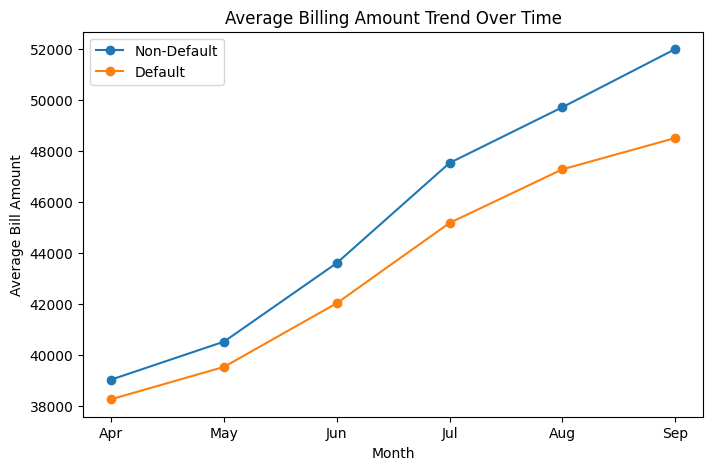

In [ ]:
bill_cols = ['BILL_AMT6','BILL_AMT5','BILL_AMT4','BILL_AMT3','BILL_AMT2','BILL_AMT1']

bill_trend = (
    df.groupby(target)[bill_cols]
    .mean()
    .T
)

bill_trend.index = ['Apr','May','Jun','Jul','Aug','Sep']
plt.figure(figsize=(8,5))
plt.plot(bill_trend.index, bill_trend[0], marker='o', label='Non-Default')
plt.plot(bill_trend.index, bill_trend[1], marker='o', label='Default')
plt.title('Average Billing Amount Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Average Bill Amount')
plt.legend()
plt.show()


### Recent vs Older Behavior Impact

In [ ]:
df['RECENT_DELAY'] = df['PAY_0']
df['PAST_DELAY_AVG'] = df[['PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)
recent_vs_past = (
    df[['RECENT_DELAY','PAST_DELAY_AVG', target]]
    .groupby(target)
    .mean()
)

recent_vs_past


,RECENT_DELAY,PAST_DELAY_AVG
DEFAULT_NEXT_MONTH,,
0,-0.211222,-0.353784
1,0.668174,0.270976


## Correlation Analysis

### Full Correlation Heatmap

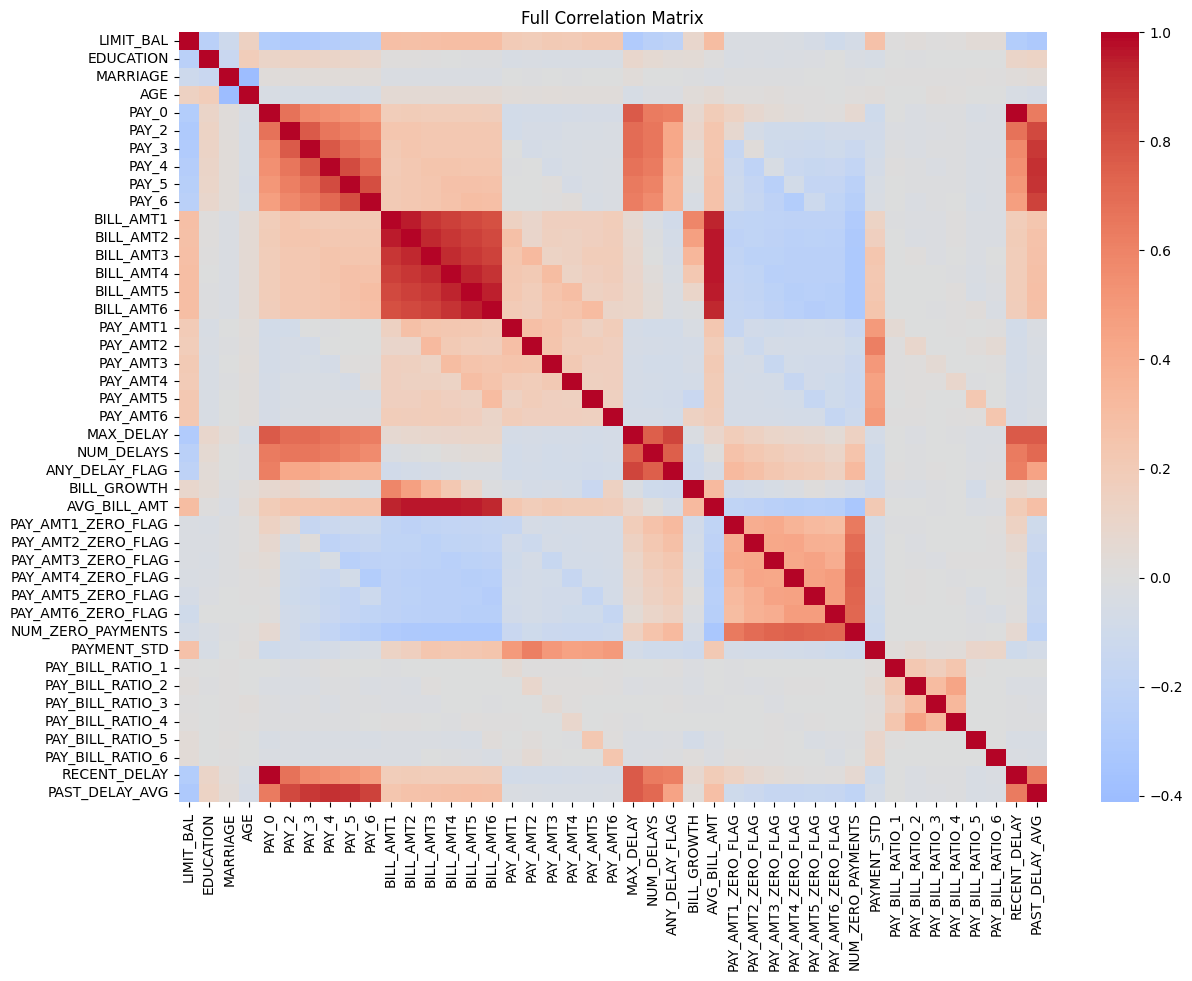

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop ID if still present
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Full Correlation Matrix")
plt.show()

### Correlation — Bill Amounts

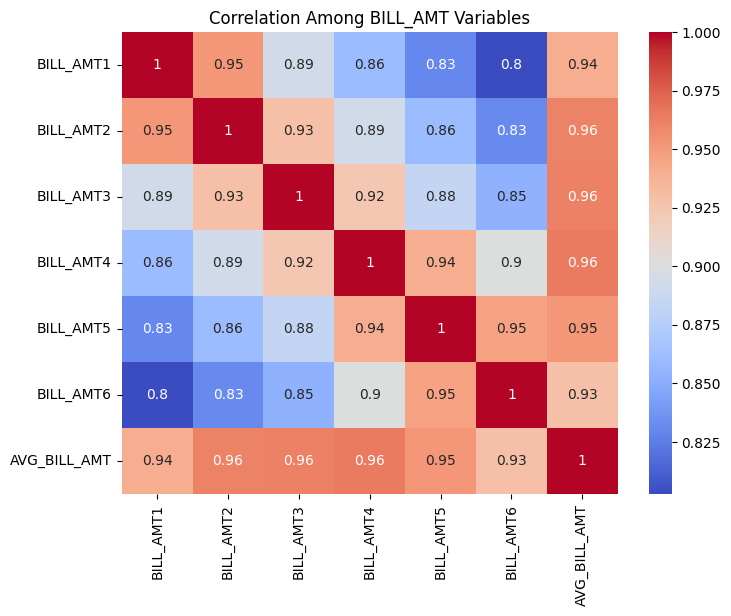

In [ ]:
bill_cols = [col for col in df.columns if 'BILL_AMT' in col]

bill_corr = df[bill_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(bill_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Among BILL_AMT Variables")
plt.show()

### Correlation — Payment Amounts

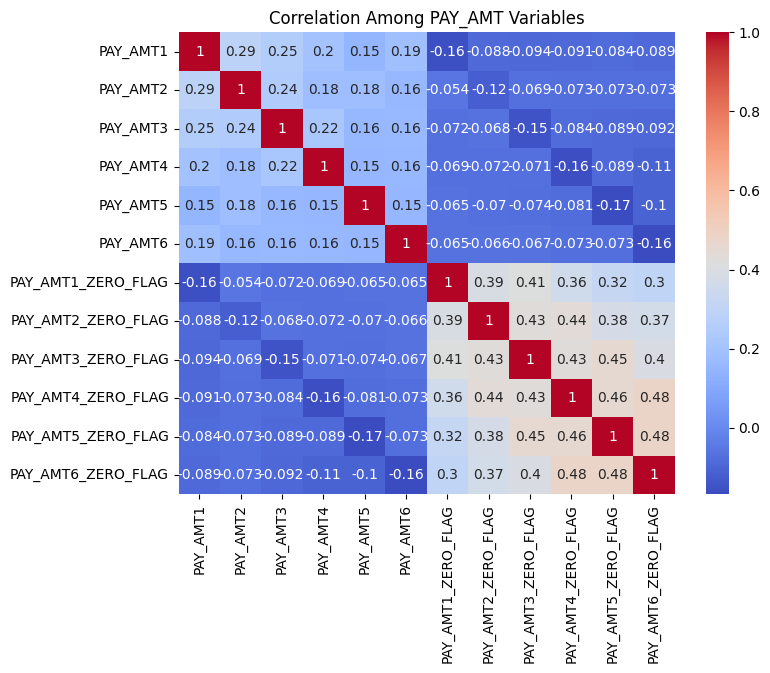

In [ ]:
pay_amt_cols = [col for col in df.columns if 'PAY_AMT' in col]

pay_amt_corr = df[pay_amt_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(pay_amt_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Among PAY_AMT Variables")
plt.show()

### Correlation — Repayment Delays

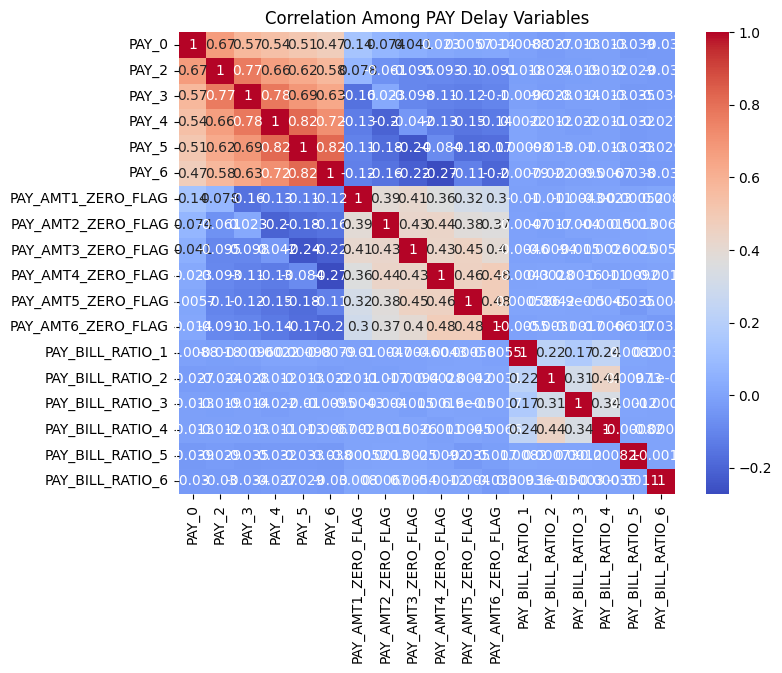

In [ ]:
pay_delay_cols = [col for col in df.columns if col.startswith('PAY_') and col != 'PAY_AMT1' and col != 'PAY_AMT2' and col != 'PAY_AMT3' and col != 'PAY_AMT4' and col != 'PAY_AMT5' and col != 'PAY_AMT6']

pay_delay_corr = df[pay_delay_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(pay_delay_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Among PAY Delay Variables")
plt.show()

In [ ]:
df.columns

Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'DEFAULT_NEXT_MONTH', 'LIMIT_BUCKET', 'MAX_DELAY', 'NUM_DELAYS',
       'ANY_DELAY_FLAG', 'BILL_GROWTH', 'BILL_GROWTH_BUCKET', 'AVG_BILL_AMT',
       'AVG_BILL_BUCKET', 'PAY_AMT1_ZERO_FLAG', 'PAY_AMT2_ZERO_FLAG',
       'PAY_AMT3_ZERO_FLAG', 'PAY_AMT4_ZERO_FLAG', 'PAY_AMT5_ZERO_FLAG',
       'PAY_AMT6_ZERO_FLAG', 'NUM_ZERO_PAYMENTS', 'PAYMENT_STD',
       'PAYMENT_STD_BUCKET', 'PAY_BILL_RATIO_1', 'PAY_BILL_RATIO_2',
       'PAY_BILL_RATIO_3', 'PAY_BILL_RATIO_4', 'PAY_BILL_RATIO_5',
       'PAY_BILL_RATIO_6', 'RECENT_DELAY', 'PAST_DELAY_AVG'],
      dtype='object')

# FEATURE ENGINEERING and MODEL BUILDING

In [ ]:
df_raw=df

In [ ]:
df_raw.head()

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH,LIMIT_BUCKET,MAX_DELAY,NUM_DELAYS,ANY_DELAY_FLAG,BILL_GROWTH,BILL_GROWTH_BUCKET,AVG_BILL_AMT,AVG_BILL_BUCKET,PAY_AMT1_ZERO_FLAG,PAY_AMT2_ZERO_FLAG,PAY_AMT3_ZERO_FLAG,PAY_AMT4_ZERO_FLAG,PAY_AMT5_ZERO_FLAG,PAY_AMT6_ZERO_FLAG,NUM_ZERO_PAYMENTS,PAYMENT_STD,PAYMENT_STD_BUCKET,PAY_BILL_RATIO_1,PAY_BILL_RATIO_2,PAY_BILL_RATIO_3,PAY_BILL_RATIO_4,PAY_BILL_RATIO_5,PAY_BILL_RATIO_6,RECENT_DELAY,PAST_DELAY_AVG
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Very Low,2,2,1,3913,Stable,1284.000000,Very Low,1,0,1,1,1,1,5,281.283072,Very Stable,0.000000,0.222115,0.000000,0.000000,0.000000,0.000000,2,-0.8
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Medium,2,2,1,-579,Moderate Decrease,2846.166667,Very Low,1,0,0,0,1,0,2,752.772653,Stable,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,-1,0.8
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Low,0,0,0,13690,Moderate Increase,16942.166667,Medium,0,0,0,0,0,0,0,1569.815488,Moderate,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0,0.0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Very Low,0,0,0,17443,Moderate Increase,38555.666667,High,0,0,0,0,0,0,0,478.058155,Very Stable,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0,0.0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Very Low,0,0,0,-10514,Sharp Decrease,18223.166667,Medium,0,0,0,0,0,0,0,13786.230736,Highly Volatile,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,-1,-0.2


In [ ]:
df_raw.columns

Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'DEFAULT_NEXT_MONTH', 'LIMIT_BUCKET', 'MAX_DELAY', 'NUM_DELAYS',
       'ANY_DELAY_FLAG', 'BILL_GROWTH', 'BILL_GROWTH_BUCKET', 'AVG_BILL_AMT',
       'AVG_BILL_BUCKET', 'PAY_AMT1_ZERO_FLAG', 'PAY_AMT2_ZERO_FLAG',
       'PAY_AMT3_ZERO_FLAG', 'PAY_AMT4_ZERO_FLAG', 'PAY_AMT5_ZERO_FLAG',
       'PAY_AMT6_ZERO_FLAG', 'NUM_ZERO_PAYMENTS', 'PAYMENT_STD',
       'PAYMENT_STD_BUCKET', 'PAY_BILL_RATIO_1', 'PAY_BILL_RATIO_2',
       'PAY_BILL_RATIO_3', 'PAY_BILL_RATIO_4', 'PAY_BILL_RATIO_5',
       'PAY_BILL_RATIO_6', 'RECENT_DELAY', 'PAST_DELAY_AVG'],
      dtype='object')

## Baseline Logistic Regression



In [ ]:
X=df_raw.drop(['DEFAULT_NEXT_MONTH','LIMIT_BUCKET','BILL_GROWTH_BUCKET','AVG_BILL_BUCKET','PAYMENT_STD_BUCKET'], axis=1)
y=df_raw['DEFAULT_NEXT_MONTH'].astype(int)

The above feature were removed because they were created for EDA purpose and not for model building

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((24000, 44), (6000, 44))

In [ ]:
X_train["GENDER"] = X_train["GENDER"].astype(int)
X_test["GENDER"] = X_test["GENDER"].astype(int)

In [ ]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
pred = log_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, pred)

print("AUC:", auc)

AUC: 0.7479020962669191


## Baseline XGBoost

In [ ]:
xgb_model = XGBClassifier(
    scale_pos_weight=3.52,   # this is 77.88 / 22.12 — fixes imbalance
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="auc"
)

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, pred_xgb)

print("XGBoost AUC:", auc_xgb)

XGBoost AUC: 0.7722359573047947


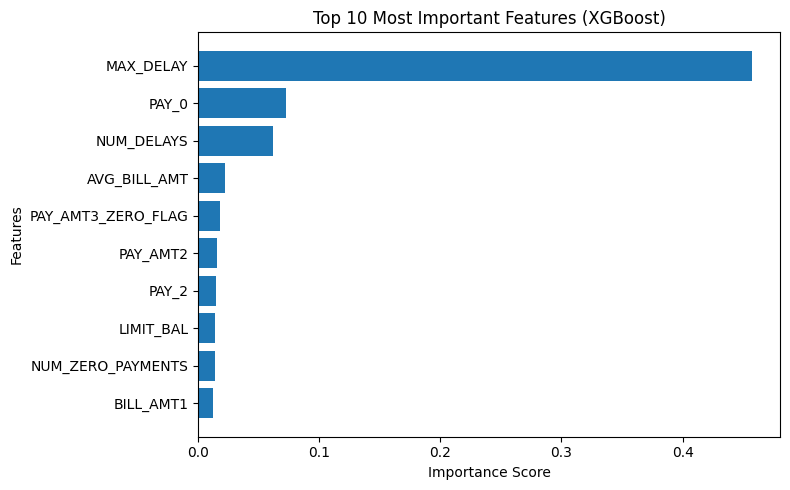

In [ ]:
# Get feature importance
importance = xgb_model.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort and select top 10
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [ ]:
feat_imp

,Feature,Importance
23,MAX_DELAY,0.457536
5,PAY_0,0.072488
24,NUM_DELAYS,0.061713
27,AVG_BILL_AMT,0.022109
30,PAY_AMT3_ZERO_FLAG,0.018070
18,PAY_AMT2,0.015258
6,PAY_2,0.015036
0,LIMIT_BAL,0.014315
34,NUM_ZERO_PAYMENTS,0.014072
11,BILL_AMT1,0.012492


## Reenginnered features used for model building

features related to payment and billing were redundant so feature transformation is applied and in above code all the features were used.

In [ ]:
# DROP REDUNDANT COLUMNS

drop_cols = [
    # individual zero flags → NUM_ZERO_PAYMENTS already has this
    'PAY_AMT1_ZERO_FLAG', 'PAY_AMT2_ZERO_FLAG', 'PAY_AMT3_ZERO_FLAG',
    'PAY_AMT4_ZERO_FLAG', 'PAY_AMT5_ZERO_FLAG', 'PAY_AMT6_ZERO_FLAG',
    # raw bills → AVG_BILL_AMT and BILL_GROWTH already cover these
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    # old pay amounts → ratios capture them better
    'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    # old ratios → keep only 1 & 2, average covers rest
    'PAY_BILL_RATIO_2','PAY_BILL_RATIO_3', 'PAY_BILL_RATIO_4',
    'PAY_BILL_RATIO_5', 'PAY_BILL_RATIO_6',
    # old pay status → MAX_DELAY and NUM_DELAYS already summarise
    'PAY_2','PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'RECENT_DELAY',
    # remove bucket feature created for EDA
    'LIMIT_BUCKET', 'BILL_GROWTH_BUCKET', 'AVG_BILL_BUCKET', 'PAYMENT_STD_BUCKET', 'ANY_DELAY_FLAG',
    'GENDER', 'MARRIAGE',
    'PAYMENT_STD'
]

df_model = df.drop(columns=drop_cols)

# ADD NEW FEATURES

df_model['AVG_PAY_BILL_RATIO'] = df[[
    'PAY_BILL_RATIO_1', 'PAY_BILL_RATIO_2', 'PAY_BILL_RATIO_3',
    'PAY_BILL_RATIO_4', 'PAY_BILL_RATIO_5', 'PAY_BILL_RATIO_6'
]].mean(axis=1)

df_model['UTILIZATION'] = (
    df_model['AVG_BILL_AMT'] / df_model['LIMIT_BAL'].replace(0, 1)
)

# TRAIN / TEST SPLIT

X = df_model.drop(columns=['DEFAULT_NEXT_MONTH'])
y = df_model['DEFAULT_NEXT_MONTH'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Default rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")


Train: 24000 rows | Test: 6000 rows
Default rate — Train: 0.221 | Test: 0.221


In [ ]:
df_model.columns

Index(['LIMIT_BAL', 'EDUCATION', 'AGE', 'PAY_0', 'PAY_AMT1',
       'DEFAULT_NEXT_MONTH', 'MAX_DELAY', 'NUM_DELAYS', 'BILL_GROWTH',
       'AVG_BILL_AMT', 'NUM_ZERO_PAYMENTS', 'PAY_BILL_RATIO_1',
       'PAST_DELAY_AVG', 'AVG_PAY_BILL_RATIO', 'UTILIZATION'],
      dtype='object')

code used after dropping gender and marraige

In [ ]:
X = df_model.drop(columns=['DEFAULT_NEXT_MONTH'])
y = df_model['DEFAULT_NEXT_MONTH'].astype(int)

# EDUCATION is the only categorical remaining
categorical_cols = ['EDUCATION']
numerical_cols   = [c for c in X.columns if c not in categorical_cols]

print("Features:", X.shape[1])
print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Default rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

# LOGISTIC REGRESSION PIPELINE

lr_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=-1), categorical_cols),
])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', lr_preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',  # handles 22% default imbalance
        max_iter=1000,
        C=0.1,                    # regularization — prevents overfitting
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f"\n🔵 Logistic Regression AUC: {lr_auc:.4f}")

# XGBOOST PIPELINE
# scale_pos_weight — fixes class imbalance (77.88 / 22.12 = 3.52)

xgb_preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=-1), categorical_cols),
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', xgb_preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=3.52,
        n_estimators=500,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.7,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        eval_metric='auc',
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
print(f"🟢 XGBoost AUC:            {xgb_auc:.4f}")

# CROSS VALIDATION ON XGBOOST
# confirms AUC is consistent across different data splits
# std < 0.01 = stable model

print("\n⏳ Running 5-fold CV...")
cv_scores = cross_val_score(
    xgb_pipeline, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f"CV scores:  {cv_scores.round(4)}")
print(f"Mean:       {cv_scores.mean():.4f}")
print(f"Std:        {cv_scores.std():.4f}  ← should be < 0.01")

# FEATURE IMPORTANCE

feature_names = numerical_cols + categorical_cols

feat_imp = pd.Series(
    xgb_pipeline.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("\n📊 Top 10 Features:")
print(feat_imp.head(10).to_string())
print("\n📊 Bottom 5 Features:")
print(feat_imp.tail(5).to_string())

Features: 14
Numerical: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_AMT1', 'MAX_DELAY', 'NUM_DELAYS', 'BILL_GROWTH', 'AVG_BILL_AMT', 'NUM_ZERO_PAYMENTS', 'PAY_BILL_RATIO_1', 'PAST_DELAY_AVG', 'AVG_PAY_BILL_RATIO', 'UTILIZATION']
Categorical: ['EDUCATION']

Train: 24000 | Test: 6000
Default rate — Train: 0.221 | Test: 0.221

🔵 Logistic Regression AUC: 0.7413
🟢 XGBoost AUC:            0.7818

⏳ Running 5-fold CV...
CV scores:  [0.7911 0.7985 0.7707 0.7936 0.7875]
Mean:       0.7883
Std:        0.0095  ← should be < 0.01

📊 Top 10 Features:
MAX_DELAY            0.395497
NUM_DELAYS           0.214507
PAY_0                0.184348
PAST_DELAY_AVG       0.033148
NUM_ZERO_PAYMENTS    0.028436
AVG_BILL_AMT         0.023013
LIMIT_BAL            0.021670
PAY_AMT1             0.019549
UTILIZATION          0.018549
BILL_GROWTH          0.013129

📊 Bottom 5 Features:
BILL_GROWTH           0.013129
AVG_PAY_BILL_RATIO    0.013110
EDUCATION             0.012900
PAY_BILL_RATIO_1      0.012145
AGE                

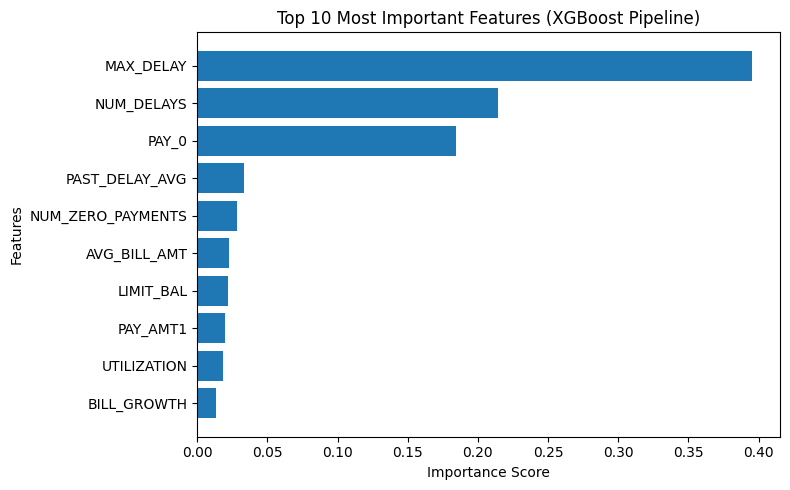

In [ ]:
# Get top 10 features
top10 = feat_imp.head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(top10.index, top10.values)
plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features (XGBoost Pipeline)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

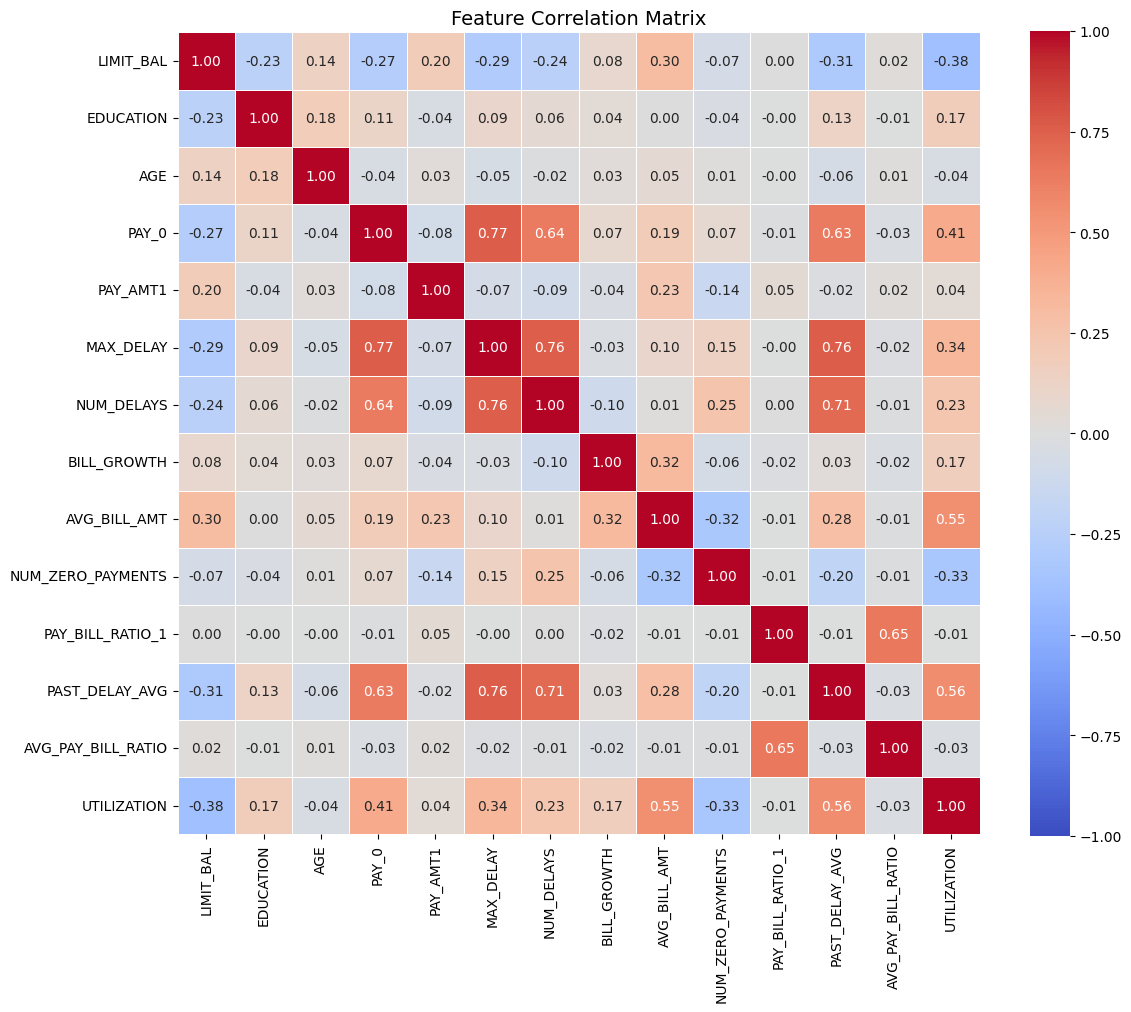

In [ ]:
# CORRELATION ANALYSIS — all features
features_only = df_model.drop(columns=['DEFAULT_NEXT_MONTH'])
corr = features_only.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# KS Statistic
def calculate_ks(y_true, y_pred_prob):
    data = pd.DataFrame({
        "target": y_true,
        "prob": y_pred_prob
    })

    data = data.sort_values(by="prob", ascending=False)

    data["cum_event"] = np.cumsum(data["target"]) / data["target"].sum()
    data["cum_non_event"] = np.cumsum(1 - data["target"]) / (1 - data["target"]).sum()

    data["ks"] = data["cum_event"] - data["cum_non_event"]

    ks_stat = np.max(data["ks"])

    return ks_stat

In [ ]:
log_pred = lr_pipeline.predict_proba(X_test)[:,1]

ks_log = calculate_ks(y_test, log_pred)

print("Logistic Regression KS:", ks_log)

Logistic Regression KS: 0.38707620022412254


In [ ]:
xgb_pred = xgb_pipeline.predict_proba(X_test)[:,1]

ks_xgb = calculate_ks(y_test, xgb_pred)

print("XGBoost KS:", ks_xgb)

XGBoost KS: 0.4379743434642177


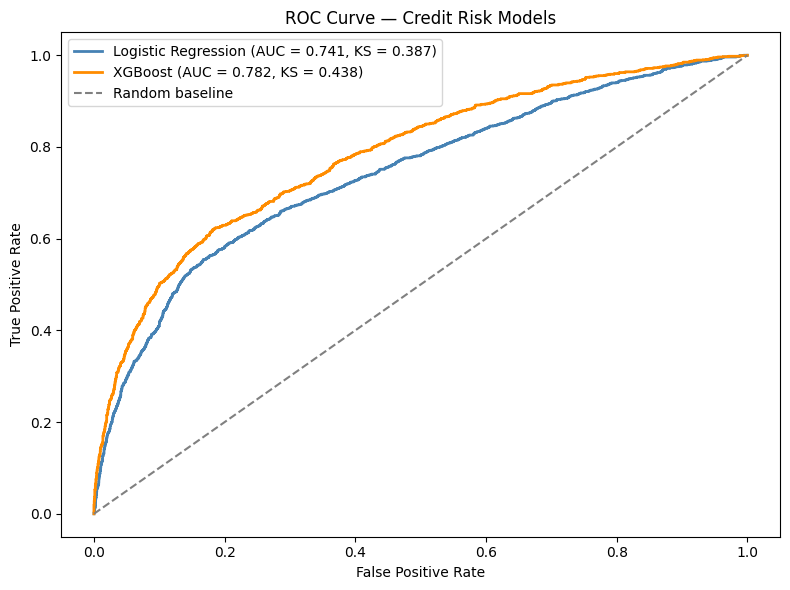

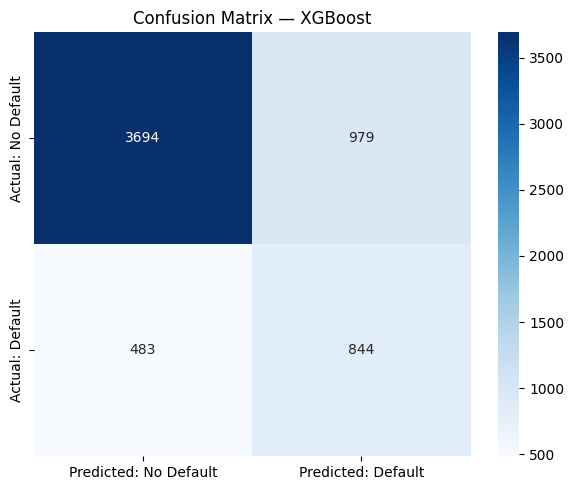

              precision    recall  f1-score   support

  No Default       0.88      0.79      0.83      4673
     Default       0.46      0.64      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



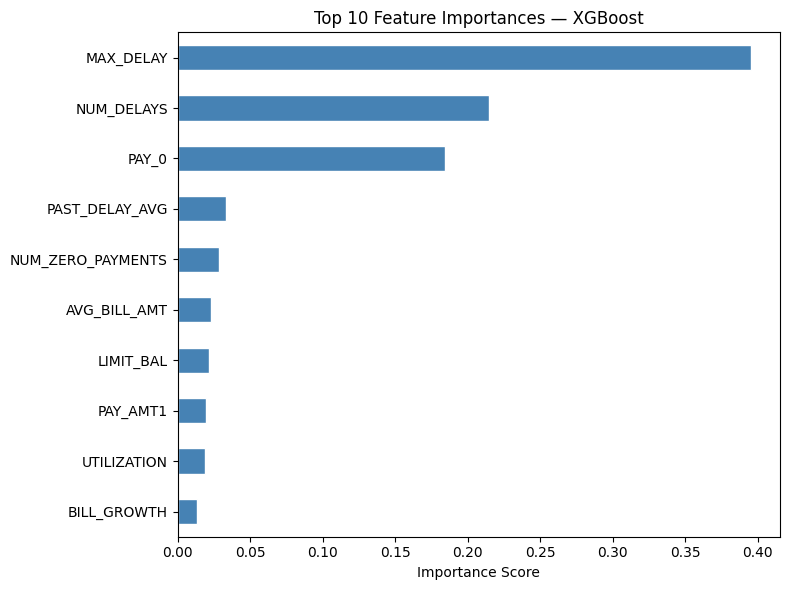

In [ ]:
from sklearn.metrics import roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ROC Curve
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,
         label=f'Logistic Regression (AUC = {lr_auc:.3f}, KS = {calculate_ks(y_test,lr_proba):.3f})',
         color='steelblue', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {xgb_auc:.3f}, KS = {calculate_ks(y_test,xgb_proba):.3f})',
         color='darkorange', linewidth=2)
plt.plot([0,1], [0,1], '--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Risk Models')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix — XGBoost
y_pred_xgb = (xgb_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Default', 'Predicted: Default'],
            yticklabels=['Actual: No Default',    'Actual: Default'])
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_xgb,
      target_names=['No Default', 'Default']))

# Feature Importance Plot
plt.figure(figsize=(8, 6))
feat_imp.head(10).sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white'
)
plt.title('Top 10 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Logistic Regression - WOE Scorecard model

In [ ]:
train, test = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model['DEFAULT_NEXT_MONTH'],
    random_state=42
)

In [ ]:
bins = sc.woebin(train, y='DEFAULT_NEXT_MONTH')

train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

X_train = train_woe.drop(columns=['DEFAULT_NEXT_MONTH'])
y_train = train_woe['DEFAULT_NEXT_MONTH'].astype(int)

X_test = test_woe.drop(columns=['DEFAULT_NEXT_MONTH'])
y_test = test_woe['DEFAULT_NEXT_MONTH'].astype(int)

[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

[INFO] converting into woe values ...
[INFO] converting into woe values ...


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred = lr.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, pred)

print("AUC:", auc)

AUC: 0.7572828951643997


In [ ]:
scorecard_pred = lr.predict_proba(X_test)[:,1]
ks_scorecard = calculate_ks(y_test, scorecard_pred)

print("Scorecard KS:", ks_scorecard)

Scorecard KS: 0.39606529259219897


In [ ]:
# Calculate Information Value (IV) of features
iv = sc.iv(train, y='DEFAULT_NEXT_MONTH')
print(iv)

              variable  info_value
4                PAY_0    0.889401
13          NUM_DELAYS    0.880204
7            MAX_DELAY    0.810116
2       PAST_DELAY_AVG    0.656096
1             PAY_AMT1    0.349318
8    NUM_ZERO_PAYMENTS    0.268833
0            LIMIT_BAL    0.213816
10         BILL_GROWTH    0.129725
6     PAY_BILL_RATIO_1    0.061483
12        AVG_BILL_AMT    0.044955
11           EDUCATION    0.036380
3                  AGE    0.032670
9   AVG_PAY_BILL_RATIO    0.032031
5          UTILIZATION    0.022718


In [ ]:
# Are any coefficients negative?
coef_check = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_check.to_string())

negatives = coef_check[coef_check['coefficient'] < 0]
if len(negatives) > 0:
    print(f"\n⚠️  Negative coefficients: {negatives['feature'].tolist()}")
else:
    print("\n✅ All positive — scorecard is clean")

                   feature  coefficient
4                PAY_0_woe     0.642245
1             PAY_AMT1_woe     0.488305
3                  AGE_woe     0.376799
5          UTILIZATION_woe     0.346608
8    NUM_ZERO_PAYMENTS_woe     0.292359
0            LIMIT_BAL_woe     0.282128
7            MAX_DELAY_woe     0.247453
9   AVG_PAY_BILL_RATIO_woe     0.243203
10         BILL_GROWTH_woe     0.238493
2       PAST_DELAY_AVG_woe     0.173232
13          NUM_DELAYS_woe     0.037866
11           EDUCATION_woe    -0.000038
12        AVG_BILL_AMT_woe    -0.055416
6     PAY_BILL_RATIO_1_woe    -0.442286

⚠️  Negative coefficients: ['EDUCATION_woe', 'AVG_BILL_AMT_woe', 'PAY_BILL_RATIO_1_woe']


In [ ]:
# Drop the 3 negative coefficient features
train_clean_sc = train.drop(columns=[
    'PAY_BILL_RATIO_1',   # negative coef, weak IV, overlaps NUM_ZERO_PAYMENTS
    'AVG_BILL_AMT',       # negative coef, weak IV, overlaps UTILIZATION
    'EDUCATION'           # effectively zero coefficient, low IV
])

test_clean_sc = test.drop(columns=[
    'PAY_BILL_RATIO_1',
    'AVG_BILL_AMT',
    'EDUCATION'
])

In [ ]:
# Rebin and retransform
bins_sc = sc.woebin(train_clean_sc, y='DEFAULT_NEXT_MONTH', no_cores=1)

train_woe_sc = sc.woebin_ply(train_clean_sc, bins_sc)
test_woe_sc  = sc.woebin_ply(test_clean_sc,  bins_sc)

X_train_sc = train_woe_sc.drop(columns=['DEFAULT_NEXT_MONTH'])
y_train_sc = train_woe_sc['DEFAULT_NEXT_MONTH'].astype(int)
X_test_sc  = test_woe_sc.drop(columns=['DEFAULT_NEXT_MONTH'])
y_test_sc  = test_woe_sc['DEFAULT_NEXT_MONTH'].astype(int)

# Refit
lr_sc = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_sc.fit(X_train_sc, y_train_sc)

pred_sc = lr_sc.predict_proba(X_test_sc)[:, 1]
auc_sc  = roc_auc_score(y_test_sc, pred_sc)
ks_sc   = calculate_ks(y_test_sc, pred_sc)

print(f"AUC: {auc_sc:.4f}")
print(f"KS:  {ks_sc:.4f}")

[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

[INFO] converting into woe values ...
[INFO] converting into woe values ...
AUC: 0.7585
KS:  0.3950


In [ ]:
# Check coefficients
coef_sc = pd.DataFrame({
    'feature':     X_train_sc.columns,
    'coefficient': lr_sc.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nCoefficients:")
print(coef_sc.to_string())

negatives = coef_sc[coef_sc['coefficient'] < 0]
if len(negatives) > 0:
    print(f"\n⚠️  Still negative: {negatives['feature'].tolist()}")
else:
    print("\n✅ All positive — ready to build scorecard")


Coefficients:
                   feature  coefficient
4                PAY_0_woe     0.644860
3                  AGE_woe     0.387146
5          UTILIZATION_woe     0.356194
0            LIMIT_BAL_woe     0.309437
6            MAX_DELAY_woe     0.286299
1             PAY_AMT1_woe     0.268398
9          BILL_GROWTH_woe     0.266972
7    NUM_ZERO_PAYMENTS_woe     0.239330
2       PAST_DELAY_AVG_woe     0.222463
8   AVG_PAY_BILL_RATIO_woe     0.128392
10          NUM_DELAYS_woe    -0.057504

⚠️  Still negative: ['NUM_DELAYS_woe']


In [ ]:
print(train_clean_sc[['NUM_DELAYS', 'MAX_DELAY', 'PAY_0']].corr())

            NUM_DELAYS  MAX_DELAY     PAY_0
NUM_DELAYS    1.000000   0.754280  0.632561
MAX_DELAY     0.754280   1.000000  0.765543
PAY_0         0.632561   0.765543  1.000000


NUM_DELAYS and MAX_DELAY are highly correlated

In [ ]:
# Drop NUM_DELAYS — captured better by MAX_DELAY
train_final_sc = train_clean_sc.drop(columns=['NUM_DELAYS'])
test_final_sc  = test_clean_sc.drop(columns=['NUM_DELAYS'])

# Rebin
bins_final_sc = sc.woebin(train_final_sc, y='DEFAULT_NEXT_MONTH', no_cores=1)

train_woe_final = sc.woebin_ply(train_final_sc, bins_final_sc)
test_woe_final  = sc.woebin_ply(test_final_sc,  bins_final_sc)

X_train_final = train_woe_final.drop(columns=['DEFAULT_NEXT_MONTH'])
y_train_final = train_woe_final['DEFAULT_NEXT_MONTH'].astype(int)
X_test_final  = test_woe_final.drop(columns=['DEFAULT_NEXT_MONTH'])
y_test_final  = test_woe_final['DEFAULT_NEXT_MONTH'].astype(int)

# Refit
lr_final_sc = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_final_sc.fit(X_train_final, y_train_final)

pred_final = lr_final_sc.predict_proba(X_test_final)[:, 1]
auc_final  = roc_auc_score(y_test_final, pred_final)
ks_final   = calculate_ks(y_test_final, pred_final)

print(f"AUC: {auc_final:.4f}")
print(f"KS:  {ks_final:.4f}")

[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

[INFO] converting into woe values ...
[INFO] converting into woe values ...
AUC: 0.7587
KS:  0.3944


In [ ]:
# Final coefficient check
coef_final = pd.DataFrame({
    'feature':     X_train_final.columns,
    'coefficient': lr_final_sc.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nCoefficients:")
print(coef_final.to_string())

negatives = coef_final[coef_final['coefficient'] < 0]
if len(negatives) > 0:
    print(f"\n⚠️  Still negative: {negatives['feature'].tolist()}")
else:
    print("\n✅ All positive — ready to build scorecard")


Coefficients:
                  feature  coefficient
4               PAY_0_woe     0.635817
3                 AGE_woe     0.386865
5         UTILIZATION_woe     0.363679
0           LIMIT_BAL_woe     0.311149
1            PAY_AMT1_woe     0.268436
9         BILL_GROWTH_woe     0.258476
6           MAX_DELAY_woe     0.252988
7   NUM_ZERO_PAYMENTS_woe     0.232295
2      PAST_DELAY_AVG_woe     0.199700
8  AVG_PAY_BILL_RATIO_woe     0.120790

✅ All positive — ready to build scorecard


In [ ]:
# BUILD SCORECARD

card = sc.scorecard(
    bins_final_sc,
    lr_final_sc,
    X_train_final.columns.tolist(),
    points0=600,    # base score — average customer gets 600
    odds0=1/9,      # base odds — 1 default for every 9 non-defaults
    pdo=20          # points to double odds — industry standard
)

# Print the scorecard — each bin gets a point value
for feature, table in card.items():
    print(f"\n{'='*50}")
    print(f"Feature: {feature}")
    print(table[['bin', 'points']].to_string())

# SCORE YOUR TEST SET

test_scores = sc.scorecard_ply(
    test_final_sc,
    card,
    print_step=0
)

# Add actual default flag
test_scores['DEFAULT_NEXT_MONTH'] = y_test_final.values

print("\nScore distribution:")
print(test_scores['score'].describe().round(1))


# DEFAULT RATE BY SCORE BAND
test_scores['score_band'] = pd.cut(
    test_scores['score'],
    bins=[0, 400, 450, 500, 550, 600, 650, 700, 850],
    labels=['<400', '400-450', '450-500', '500-550',
            '550-600', '600-650', '650-700', '>700']
)

band_summary = test_scores.groupby('score_band', observed=True).agg(
    count=('score', 'count'),
    defaults=('DEFAULT_NEXT_MONTH', 'sum'),
    default_rate=('DEFAULT_NEXT_MONTH', 'mean')
).round(3)

print("\nDefault Rate by Score Band:")
print(band_summary.to_string())


Feature: basepoints
   bin  points
0  NaN   573.0

Feature: LIMIT_BAL
                   bin  points
0       [-inf,40000.0)    -6.0
1   [40000.0,140000.0)    -2.0
2  [140000.0,260000.0)     2.0
3       [260000.0,inf)     6.0

Feature: PAY_AMT1
                bin  points
4      [-inf,500.0)    -4.0
5    [500.0,4000.0)    -0.0
6  [4000.0,17500.0)     3.0
7     [17500.0,inf)     8.0

Feature: PAST_DELAY_AVG
                                         bin  points
8                 [-inf,-1.0000000000000002)     2.0
9   [-1.0000000000000002,0.1999999999999993)     3.0
10   [0.1999999999999993,0.9999999999999991)    -4.0
11                  [0.9999999999999991,inf)   -10.0

Feature: AGE
            bin  points
12  [-inf,24.0)    -4.0
13  [24.0,26.0)    -2.0
14  [26.0,36.0)     2.0
15  [36.0,46.0)     0.0
16   [46.0,inf)    -2.0

Feature: PAY_0
           bin  points
17  [-inf,0.0)     8.0
18   [0.0,1.0)    12.0
19   [1.0,2.0)   -11.0
20   [2.0,inf)   -38.0

Feature: UTILIZATION
              

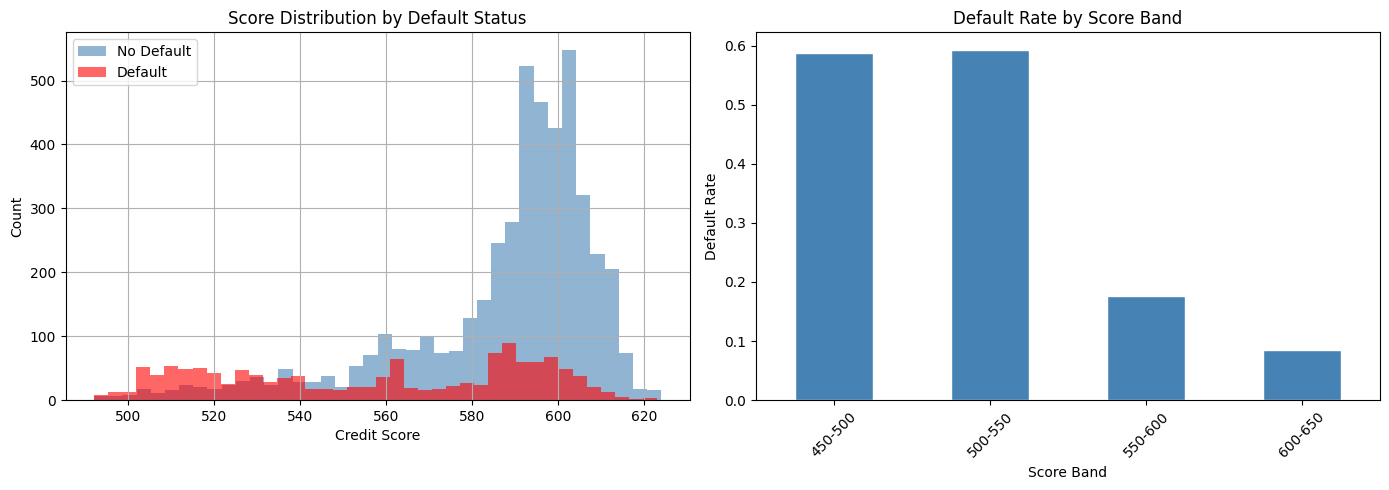

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by default status
test_scores[test_scores['DEFAULT_NEXT_MONTH']==0]['score'].hist(
    bins=40, ax=axes[0], alpha=0.6, color='steelblue', label='No Default'
)
test_scores[test_scores['DEFAULT_NEXT_MONTH']==1]['score'].hist(
    bins=40, ax=axes[0], alpha=0.6, color='red', label='Default'
)
axes[0].set_title('Score Distribution by Default Status')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Default rate by score band
band_summary['default_rate'].plot(
    kind='bar', ax=axes[1],
    color='steelblue', edgecolor='white'
)
axes[1].set_title('Default Rate by Score Band')
axes[1].set_xlabel('Score Band')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Final Complete Scorecard Model

In [ ]:
# Fix UTILIZATION bins + rebin all features
breaks_corrected = {
    'UTILIZATION': [0.10, 0.50, 0.80],
}

bins_corrected = sc.woebin(
    train_final_sc,
    y='DEFAULT_NEXT_MONTH',
    breaks_list=breaks_corrected,
    no_cores=1
)

# WOE transform
train_woe_c = sc.woebin_ply(train_final_sc, bins_corrected)
test_woe_c  = sc.woebin_ply(test_final_sc,  bins_corrected)

X_train_c = train_woe_c.drop(columns=['DEFAULT_NEXT_MONTH'])
y_train_c = train_woe_c['DEFAULT_NEXT_MONTH'].astype(int)
X_test_c  = test_woe_c.drop(columns=['DEFAULT_NEXT_MONTH'])
y_test_c  = test_woe_c['DEFAULT_NEXT_MONTH'].astype(int)

# Refit LR
lr_c = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_c.fit(X_train_c, y_train_c)

pred_c = lr_c.predict_proba(X_test_c)[:, 1]
print(f"AUC: {roc_auc_score(y_test_c, pred_c):.4f}")

[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

[INFO] converting into woe values ...
[INFO] converting into woe values ...
AUC: 0.7580


In [ ]:
# Coefficient check
coef_c = pd.DataFrame({
    'feature':     X_train_c.columns,
    'coefficient': lr_c.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nCoefficients:")
print(coef_c.to_string())

negatives = coef_c[coef_c['coefficient'] < 0]
if len(negatives) > 0:
    print(f"\n⚠️  Negative: {negatives['feature'].tolist()}")
else:
    print("\n✅ All positive")


Coefficients:
                  feature  coefficient
4               PAY_0_woe     0.637225
3                 AGE_woe     0.383366
5         UTILIZATION_woe     0.355377
0           LIMIT_BAL_woe     0.302834
1            PAY_AMT1_woe     0.280693
9         BILL_GROWTH_woe     0.269564
6           MAX_DELAY_woe     0.251520
7   NUM_ZERO_PAYMENTS_woe     0.239340
2      PAST_DELAY_AVG_woe     0.195495
8  AVG_PAY_BILL_RATIO_woe     0.115762

✅ All positive


In [ ]:
# Build scorecard
n_default     = y_train_c.sum()
n_non_default = len(y_train_c) - n_default
actual_odds   = n_non_default / n_default
print(f"\nActual odds: {actual_odds:.2f}")

card_corrected = sc.scorecard(
    bins_corrected,
    lr_c,
    X_train_c.columns.tolist(),
    points0=600,
    odds0=actual_odds,
    pdo=50
)


Actual odds: 3.52


In [ ]:
# Score test set
test_scores_c = sc.scorecard_ply(
    test_final_sc,
    card_corrected,
    print_step=0
)
test_scores_c['DEFAULT_NEXT_MONTH'] = y_test_final.values

print("\nScore distribution:")
print(test_scores_c['score'].describe().round(1))


Score distribution:
count    6000.0
mean      799.9
std        73.6
min       576.0
25%       764.0
50%       828.0
75%       851.0
max       906.0
Name: score, dtype: float64


In [ ]:
# Score bands
test_scores_c['score_band_final'] = pd.cut(
    test_scores_c['score'],
    bins=[0, 650, 700, 750, 800, 850, 1000],
    labels=['<650','650-700','700-750','750-800','800-850','>850']
)

band_final = test_scores_c.groupby(
    'score_band_final', observed=True
).agg(
    count=('score','count'),
    defaults=('DEFAULT_NEXT_MONTH','sum'),
    default_rate=('DEFAULT_NEXT_MONTH','mean')
).round(3)

print("\nFinal Scorecard Validation:")
print(band_final[band_final['count'] > 0].to_string())


Final Scorecard Validation:
                  count  defaults  default_rate
score_band_final                               
<650                429       305         0.711
650-700             409       219         0.535
700-750             456       141         0.309
750-800             695       165         0.237
800-850            2443       368         0.151
>850               1568       129         0.082


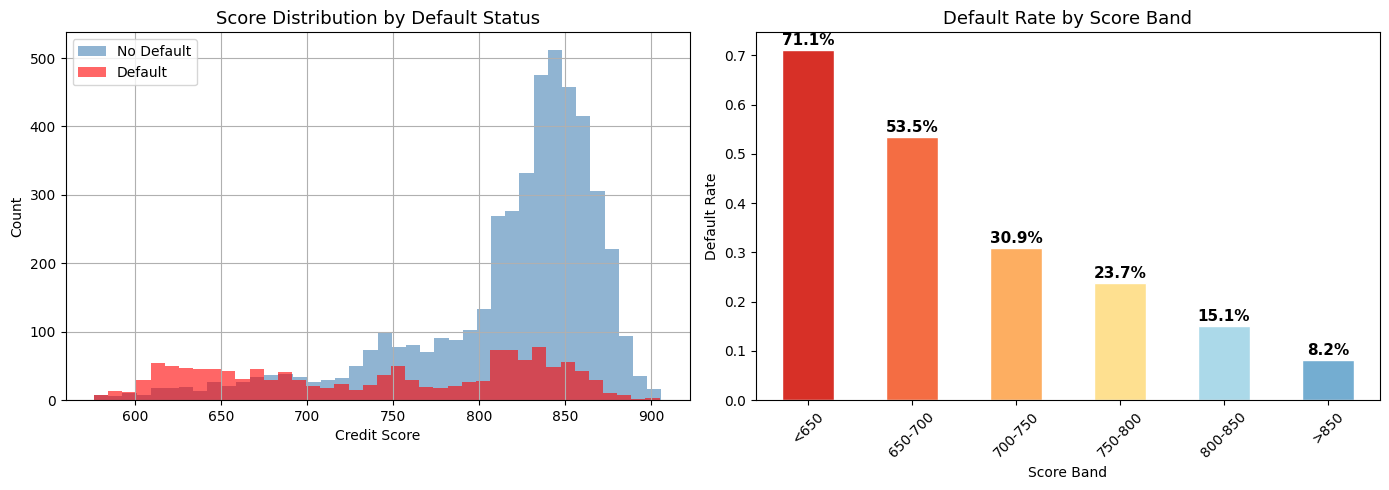

In [ ]:
#Visualization
band_plot = band_final[band_final['count'] > 0]
colors    = ['#d73027','#f46d43','#fdae61',
             '#fee090','#abd9e9','#74add1'][:len(band_plot)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
test_scores_c[test_scores_c['DEFAULT_NEXT_MONTH']==0]['score'].hist(
    bins=40, ax=axes[0], alpha=0.6,
    color='steelblue', label='No Default'
)
test_scores_c[test_scores_c['DEFAULT_NEXT_MONTH']==1]['score'].hist(
    bins=40, ax=axes[0], alpha=0.6,
    color='red', label='Default'
)
axes[0].set_title('Score Distribution by Default Status', fontsize=13)
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Default rate by band
band_plot['default_rate'].plot(
    kind='bar', ax=axes[1],
    color=colors, edgecolor='white'
)
axes[1].set_title('Default Rate by Score Band', fontsize=13)
axes[1].set_xlabel('Score Band')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(band_plot['default_rate']):
    axes[1].text(i, v + 0.01, f'{v:.1%}',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('scorecard_final.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# scorecard points table
print("FULL SCORECARD POINTS TABLE")

for feature, table in card_corrected.items():
    print(f"\n{'='*50}")
    print(f"Feature: {feature}")
    print(table[['bin', 'points']].to_string())

FULL SCORECARD POINTS TABLE

Feature: basepoints
   bin  points
0  NaN   781.0

Feature: LIMIT_BAL
                   bin  points
0       [-inf,40000.0)   -15.0
1   [40000.0,140000.0)    -4.0
2  [140000.0,260000.0)     6.0
3       [260000.0,inf)    14.0

Feature: PAY_AMT1
                bin  points
4      [-inf,500.0)   -11.0
5    [500.0,4000.0)    -0.0
6  [4000.0,17500.0)     9.0
7     [17500.0,inf)    21.0

Feature: PAST_DELAY_AVG
                                         bin  points
8                 [-inf,-1.0000000000000002)     4.0
9   [-1.0000000000000002,0.1999999999999993)     8.0
10   [0.1999999999999993,0.9999999999999991)   -10.0
11                  [0.9999999999999991,inf)   -24.0

Feature: AGE
            bin  points
12  [-inf,24.0)    -9.0
13  [24.0,26.0)    -6.0
14  [26.0,36.0)     4.0
15  [36.0,46.0)     1.0
16   [46.0,inf)    -5.0

Feature: PAY_0
           bin  points
17  [-inf,0.0)    21.0
18   [0.0,1.0)    30.0
19   [1.0,2.0)   -28.0
20   [2.0,inf)   -96.0

Feature

## Save Artifacts

In [ ]:
# Save model
joblib.dump(lr_pipeline, "logistic_model.joblib")
joblib.dump(xgb_pipeline, "xgboost_model.joblib")
joblib.dump(lr_c, "scorecard_model.joblib")  # WOE logistic

['scorecard_model.joblib']

In [ ]:
# Save woe bins created
joblib.dump(bins_corrected, "artifacts/preprocessing/woe_bins.joblib")

In [ ]:
feature_columns_scorecard = list(X_train_c.columns)

print(feature_columns_scorecard)

['LIMIT_BAL_woe', 'PAY_AMT1_woe', 'PAST_DELAY_AVG_woe', 'AGE_woe', 'PAY_0_woe', 'UTILIZATION_woe', 'MAX_DELAY_woe', 'NUM_ZERO_PAYMENTS_woe', 'AVG_PAY_BILL_RATIO_woe', 'BILL_GROWTH_woe']


In [ ]:
# save scorecard model feature columns
json.dump(feature_columns_scorecard, open("feature_columns_scorecard.json", "w"))

In [ ]:
# save XGBoost model feature columns
feature_columns_xgb = numerical_cols + categorical_cols
json.dump(feature_columns_xgb, open("feature_columns_xgb.json", "w"))